# Semi-supervised GMM

## Setup

In [1]:
from pathlib import Path
from pprint import pprint
import datetime as dt
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp, kl_div, rel_entr
from scipy.integrate import quad

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


In [2]:
from segmentation_utils import (
    get_ground_truth_segmentation,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
# plt.rcParams['text.latex.preamble']=r"\usepackage{bm}"

In [4]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Hyperparameters

In [5]:
# seed = 0
seed = 42
seq_length = 2**10
print(f"Sequence_length: {seq_length}")
rng = np.random.default_rng(seed)
window_size = 20
window_step = 5
smoothing_factor = 0

Sequence_length: 1024


In [6]:
# max_iter = 300
tol = 1e-3
beta = 0.5

In [7]:
# Make transparent background plot
TRANSP_BACK_PLOT = True
# TRANSP_BACK_PLOT = False

## Data

In [8]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [9]:
means = np.array(
    [
        [0, 3],
        [3, 1],
        [2.0, 2.0],
    ]
)
covs = np.eye(2) * 0.5
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1024, 2)

In [10]:
K_components = data.shape[0]

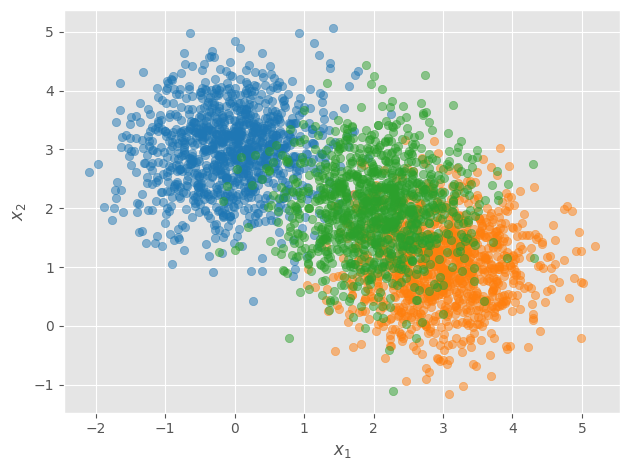

In [11]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx], alpha=0.5)
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

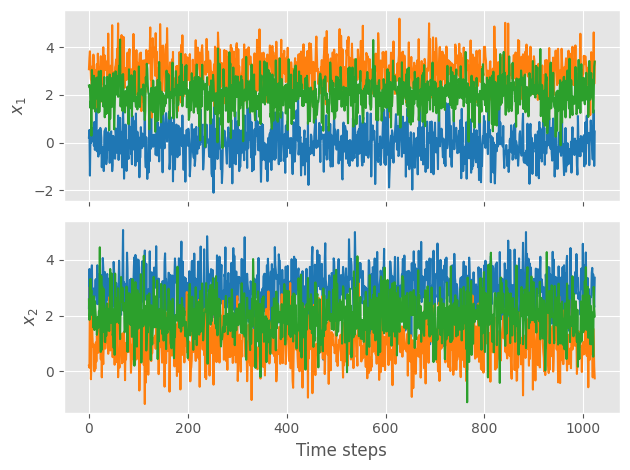

In [12]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [13]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [14]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [15]:
def features_augment(df, window_size, min_periods):
    skip_col = ["label_true"]
    freeze_cols = df.columns
    for col in freeze_cols:
        if col in skip_col:
            continue
        df[f"{col}_roll_mean"] = df[col].rolling(window=window_size).mean()
        df[f"{col}_roll_max"] = df[col].rolling(window=window_size).max()
        df[f"{col}_roll_min"] = df[col].rolling(window=window_size).min()
        df[f"{col}_roll_std"] = df[col].rolling(window=window_size).std()
        df[f"{col}_roll_quantile"] = df[col].rolling(window=window_size).quantile(0.25)
        df[f"{col}_expand_mean"] = df[col].expanding(min_periods=min_periods).mean()
        df[f"{col}_expand_max"] = df[col].expanding(min_periods=min_periods).max()
        df[f"{col}_expand_min"] = df[col].expanding(min_periods=min_periods).min()
        df[f"{col}_expand_std"] = df[col].expanding(min_periods=min_periods).std()
        df[f"{col}_expand_quantile"] = (
            df[col].expanding(min_periods=min_periods).quantile(0.25)
        )
    df = df.fillna(0)
    return df, freeze_cols

In [16]:
def sliding_window(series, window_size, step=1):
    windows = []
    for idx in range(0, len(series) - window_size + 1, step):
        windows.append(series[idx : idx + window_size])
    return np.array(windows)

In [17]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 201, 20, 2)

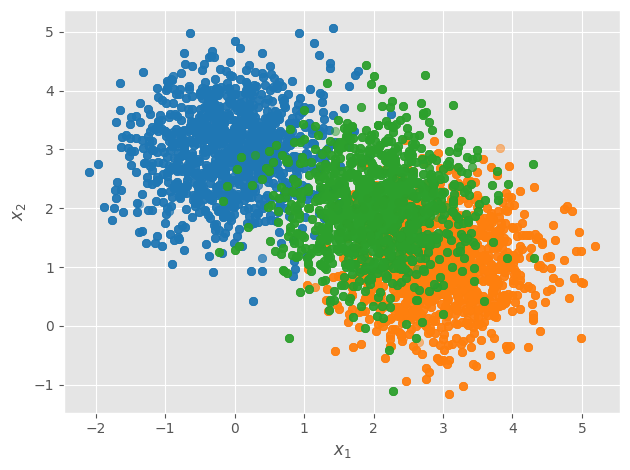

In [18]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0],
                windows[idx, jdx, :, 1],
                color=cmap[idx],
                alpha=0.5,
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

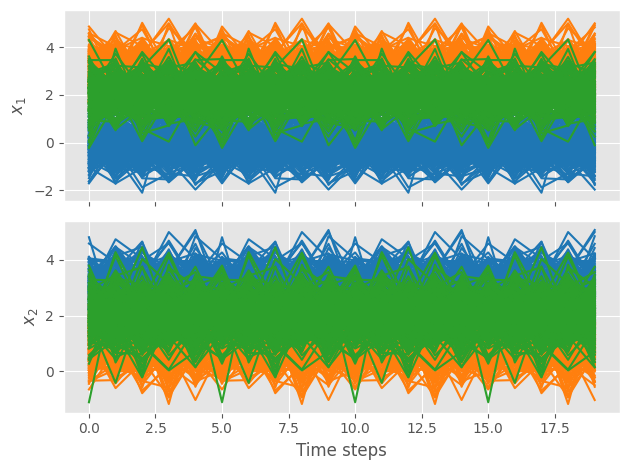

In [19]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [20]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [21]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
            # ToDo: add curvature feature
        ]
        features.append(feats)
    return np.array(features)

In [22]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 201, 33)

In [23]:
labels_gt = (
    np.array([np.ones(features.shape[1]) * idx for idx in range(features.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [24]:
labels_gt = (
    np.array([np.ones(data.shape[1]) * idx for idx in range(data.shape[0])])
    .flatten()
    .astype(int)
)
labels_gt

array([0, 0, 0, ..., 2, 2, 2], shape=(3072,))

In [25]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,7.235145,172.491524,54.383649,1.654052,0.750416,0.306583,11.825866,7.015794,7.139521,2.211940,...,0.0,0.0,0.0,1.0,2.119709,0.892480,-0.386215,0.389880,0.602662,0.962716
1,6.110177,186.832273,55.321601,1.741174,0.135222,0.251848,13.616710,7.348869,6.469934,0.732647,...,0.0,0.0,0.0,1.0,2.196261,0.976915,0.412449,0.014447,0.891917,0.890809
2,6.784973,196.010353,60.652159,1.713942,0.583863,0.237151,14.776973,6.487957,6.554335,0.533683,...,0.0,0.0,0.0,1.0,2.251640,0.704447,0.482092,0.242589,2.659491,1.014196
3,7.813056,199.532044,62.516367,1.823373,0.694954,0.237151,14.991877,5.827306,6.966480,0.410811,...,0.0,0.0,0.0,1.0,2.276758,0.705570,0.224241,0.171653,0.813215,1.060531
4,6.385922,199.763094,64.882107,1.887972,0.677852,0.212778,15.138575,5.984406,6.321674,-0.969778,...,0.0,0.0,0.0,1.0,2.270182,0.682676,-0.372318,-0.066416,-1.996714,1.123544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,105.788495,61.231631,15.510909,0.628022,0.900491,0.936042,6.973985,5.867597,6.032309,-0.780458,...,0.0,0.0,0.0,1.0,2.043405,0.476924,0.417217,0.062333,1.716698,0.413652
599,107.927534,62.466529,16.828112,0.860887,0.813453,0.964067,7.763762,5.988691,6.056667,-0.676358,...,0.0,0.0,0.0,1.0,2.063941,0.476924,0.223615,0.300656,2.368390,0.410440
600,113.038695,79.395529,18.923411,0.414130,0.813453,0.955663,9.655573,5.960147,5.794001,-0.573397,...,0.0,0.0,0.0,1.0,2.193366,0.371564,0.397541,0.802024,0.551755,0.373770
601,106.436201,89.702187,14.679734,-0.409498,0.847797,0.962863,8.950298,6.122521,6.795532,-0.260859,...,0.0,0.0,0.0,1.0,2.214376,0.342945,0.279104,0.846640,-0.895873,0.321887


In [26]:
feat_mat = data.reshape(data.shape[0] * data.shape[1], data.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1
0,0.215468,2.264620
1,0.530649,3.665080
2,-1.379590,2.079220
3,0.090397,2.776383
4,-0.011880,2.396807
...,...,...
3067,2.520470,1.985507
3068,1.251430,0.525961
3069,1.903499,3.023688
3070,3.184181,2.251289


In [27]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

### Supervised data

In [28]:
def select_supervised_data(total_sample_size, labels_gt, K_components, U):
    unique_labels = np.unique(labels_gt)
    label_sample_size = int(np.round(total_sample_size / len(unique_labels)))

    # Select balanced data for each label
    all_idx = np.arange(labels_gt.shape[0])
    idx_superv = []
    for label in unique_labels:
        if np.isnan(label):
            continue
        current_label_mask = labels_gt == label
        current_label_idx = np.array(
            [idx for idx in all_idx if current_label_mask[idx] == True]
        )
        assert len(current_label_idx) >= label_sample_size, (
            f"Not enough data points to select {label_sample_size} samples for class {label}, only {len(current_label_idx)} found"
        )
        idx_superv.extend(
            np.random.choice(current_label_idx, size=label_sample_size, replace=False)
        )
    idx_superv = np.array(idx_superv)

    # Build the Y matrix
    Y = np.zeros((len(idx_superv), K_components)).astype(int)
    for idxi, idx_val in enumerate(idx_superv):
        Y[idxi, int(labels_gt[int(idx_val)])] = 1

    X = U[idx_superv, :]
    return X, Y, idx_superv

In [29]:
supervised_sample_size = 10
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=labels_gt,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((9, 2),
 array([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1]]))

## GMM clustering

In [30]:
def e_step(U, pi_mixing_prior, mu, Sigma, seed=None, allow_singular=False):
    """
    Compute the expectation step (equation 4).

    U: unlabeled training data
    """
    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)
    return gamma_resp

In [31]:
def m_step(gamma_resp, U, X=None, Y=None, beta=0.5, reg_coef=1e-3):
    """
    Compute the maximization step.
    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0
        M = 0
    else:
        assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
        assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
        M, _ = X.shape
    N, D = U.shape
    K = gamma_resp.shape[1]

    pi_mixing_prior_new = np.zeros(K) * np.nan
    mu_new = np.zeros((K, D)) * np.nan
    Sigma_new = np.zeros((K, D, D)) * np.nan

    for k in range(K):
        if beta == 0:
            common_term = (1 - beta) * gamma_resp.sum(axis=0)[k]
        else:
            common_term = (1 - beta) * gamma_resp.sum(axis=0)[k] + beta * Y.sum(axis=0)[
                k
            ]

        # Update mixing coefficients (equation 5)
        pi_mixing_prior_new[k] = common_term / ((1 - beta) * N + beta * M)

        # Update means (equation 6)
        gamma_resp_u = 0
        gamma_resp_x = 0
        for n in range(N):
            gamma_resp_u += gamma_resp[n, k] * U[n, :]
        if beta == 0:
            gamma_resp_x = 0
        else:
            for m in range(M):
                gamma_resp_x += gamma_resp[m, k] * X[m, :]
        mu_new[k, :] = ((1 - beta) * gamma_resp_u + beta * gamma_resp_x) / common_term

        # Update covariances (equation 7)
        gamma_resp_u_mu = 0
        gamma_resp_x_mu = 0
        for n in range(N):
            gamma_resp_u_mu += (
                gamma_resp[n, k] * (U[n, :] - mu_new[k]) * (U[n, :] - mu_new[k]).T
            )
        if beta == 0:
            gamma_resp_x_mu = 0
        else:
            for m in range(M):
                gamma_resp_x_mu += (
                    gamma_resp[n, k] * (X[m, :] - mu_new[k]) * (X[m, :] - mu_new[k]).T
                )
        # Sigma_new[k] = ((1 - beta) * gamma_resp_u_mu) / common_term + (
        #     beta * gamma_resp_x_mu
        # ) / common_term
        var = ((1 - beta) * gamma_resp_u_mu) / common_term + (
            beta * gamma_resp_x_mu
        ) / common_term
        # var = 1/2*(var + var.T)  # Semi Positive Definite issue
        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[k] += reg_coef*np.eye(D)

        # # Constrain the covariance matrices to be diagonal
        # var = (gamma_resp[:, k][:, None] * diff**2).sum(axis=0) / Nk[k]
        Sigma_new[k] = np.diag(var + reg_coef)
    return pi_mixing_prior_new, mu_new, Sigma_new

In [32]:
def log_likelihood(
    pi_mixing_prior, mu, Sigma, U, X=None, Y=None, beta=0.5, allow_singular=False
):
    """
    Compute the log-likelihood (equation 9).
    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0
    else:
        assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
        assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
        M, _ = X.shape
    N, D = U.shape
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    log_lik_unsuperv = np.zeros((N, K))
    log_lik_superv = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    log_lik_unsuperv = (1 - beta) * log_norm.sum(axis=0)

    if beta == 0:
        log_lik_superv = 0
    else:
        for m in range(M):
            for k in range(K):
                # ToDo: may need to convert the multiplication by `Y[m, k]` to a sum of log
                log_lik_superv[m, k] = Y[m, k] * np.log(
                    pi_mixing_prior[k]
                ) + multivariate_normal.logpdf(
                    x=X[m, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
                )
        log_lik_superv = beta * log_lik_superv.sum()

    return log_lik_unsuperv + log_lik_superv

In [33]:
def run_EM(
    K_components,
    U,
    X=None,
    Y=None,
    beta=0.5,
    reg_coef=1e-3,
    max_iter=300,
    tol=1e-6,
    seed=None,
    allow_singular=False,
):
    """
    Expectation-Maximization algorithm.

    Implemented from [1].

    [1] Yan, H.-C., Zhou, J.-H., & Pang, C. K. (2017).
    Gaussian Mixture Model Using Semisupervised Learning for Probabilistic Fault Diagnosis Under New Data Categories.
    IEEE Transactions on Instrumentation and Measurement, 66(4), 723–733.
    https://doi.org/10.1109/TIM.2017.2654552

    """
    if X is None or Y is None:
        # Fall back to unsupervised
        beta = 0

    # Initialization
    N, D = U.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=U)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            U=U, X=X, Y=Y, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(
            U=U,
            X=X,
            Y=Y,
            pi_mixing_prior=pi_mixing_prior,
            mu=mu,
            Sigma=Sigma,
            allow_singular=allow_singular,
        )
        lls.append(ll)

        # Logging during training
        if it % 10 == 0:
            # plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')
            print(f"Iteration {it:>3}/{max_iter} -- Log-likelihood: {ll[0]}")

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"\n--- Converged at iteration {it + 1} ---\n")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("EM training")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [34]:
def predict(U, pi_mixing_prior, mu, Sigma, allow_singular=False, seed=None):
    gamma_resp = e_step(
        U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    uncertainty = 1 - gamma_resp.max(axis=1)
    labels_pred = np.argmax(gamma_resp, axis=1)

    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    # proba = np.exp(log_probs.sum(axis=1))
    proba = np.exp(log_probs).sum(axis=1)
    # proba = logsumexp(log_probs, axis=1)

    return gamma_resp, labels_pred, uncertainty, proba

In [35]:
# def predict(U, pi_mixing_prior, mu, Sigma, allow_singular=False, seed=None):
#     gamma_resp = e_step(
#         U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
#     )
#     uncertainty = 1 - gamma_resp.max(axis=1)
#     labels_pred = np.argmax(gamma_resp, axis=1)

#     N = U.shape[0]
#     K = pi_mixing_prior.shape[0]
#     proba = np.zeros((N, K))

#     for k in range(K):
#         proba[:, k] = pi_mixing_prior[k]*multivariate_normal.pdf(
#             x=U, mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
#         )

#     # # Todo: Uncomment
#     # np.testing.assert_allclose(proba.sum(), 1)
#     return gamma_resp, labels_pred, uncertainty, proba

Iteration   0/300 -- Log-likelihood: -4576.90804786328
Iteration  10/300 -- Log-likelihood: -4558.1813460728545
Iteration  20/300 -- Log-likelihood: -4557.9085308247395
Iteration  30/300 -- Log-likelihood: -4557.785543002797
Iteration  40/300 -- Log-likelihood: -4557.713979283654
Iteration  50/300 -- Log-likelihood: -4557.667764918878
Iteration  60/300 -- Log-likelihood: -4557.6374214147045
Iteration  70/300 -- Log-likelihood: -4557.617402960875
Iteration  80/300 -- Log-likelihood: -4557.604109788077

--- Converged at iteration 84 ---



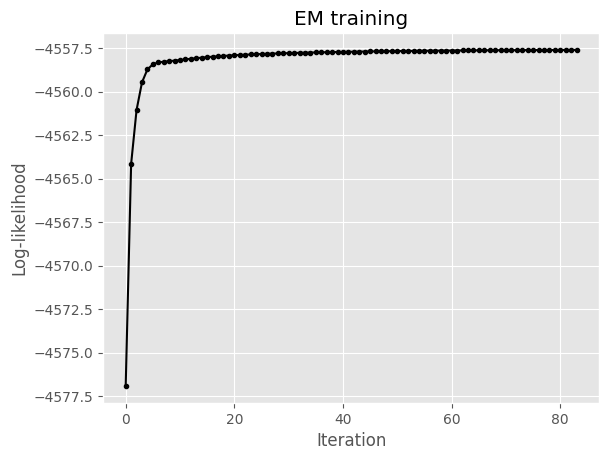

In [36]:
reg_coef = 1e-5
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [37]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 2.91137481,  1.0769898 ],
        [ 1.99918775,  2.05359819],
        [-0.03368987,  2.97338991]]),
 array([[[0.5769919 , 0.        ],
         [0.        , 0.52834721]],
 
        [[0.4247864 , 0.        ],
         [0.        , 0.55696735]],
 
        [[0.48191393, 0.        ],
         [0.        , 0.49519554]]]),
 array([[8.26882530e-04, 3.29246362e-02, 9.66248481e-01],
        [2.88262058e-05, 1.44511881e-02, 9.85519986e-01],
        [6.65587051e-07, 1.81665071e-05, 9.99981168e-01],
        ...,
        [2.92686099e-02, 9.18850726e-01, 5.18806642e-02],
        [6.18365016e-01, 3.81603922e-01, 3.10620163e-05],
        [8.15816046e-01, 1.84179884e-01, 4.07007387e-06]], shape=(3072, 3)),
 array([2, 2, 2, ..., 1, 0, 0], shape=(3072,)),
 array([0.37991497, 0.28367968, 0.33640534]))

In [38]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [39]:
# accu = accuracy_score(y_true=labels_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [40]:
def print_metrics(X, labels_true, labels_pred):
    print(f"Silhouette: {metrics.silhouette_score(X=X, labels=labels_pred)}")
    print(
        f"Completeness: {metrics.completeness_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Homogeneity: {metrics.homogeneity_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Mutual Information: {metrics.mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Rand index: {metrics.rand_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )
    print(
        f"V-measure: {metrics.v_measure_score(labels_true=labels_true, labels_pred=labels_pred)}"
    )

In [41]:
print_metrics(X=feat_mat, labels_true=labels_gt, labels_pred=clust_labels_pred)

Silhouette: 0.40077538366864784
Completeness: 0.6080495159605394
Fowlkes-Mallows index: 0.7513536171957919
Homogeneity: 0.6039403146196933
Mutual Information: 0.6634962512632797
Adjusted mutual information: 0.6057533177863834
Normalized Mutual Information: 0.6059879492516094
Rand index: 0.8331041649706936
Adjusted rand index: 0.6257481380706446
V-measure: 0.6059879492516095


In [42]:
def plot_cluster_res3(U, X, Y, labels_gt, labels_pred, gamma_resp, mu):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    uncertainty = 1 - gamma_resp.max(axis=1)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
        ax[0].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_gt, alpha=0.5, s=20)
        ax[0].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0].set_title("True clusters")
        ax[1].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_pred, alpha=0.5, s=20)
        ax[1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="x",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[1].set_title("Predicted clusters")
        ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
        ax[2].set_title("Uncertainty")
        for axi in ax:
            axi.set_xlabel("PC 1")
            axi.set_ylabel("PC 2")
        for axi in ax[:2]:
            axi.legend(
                loc="best", facecolor="white"
            )  # , edgecolor='black', fancybox=True)
        fig.tight_layout()
        plt.show()

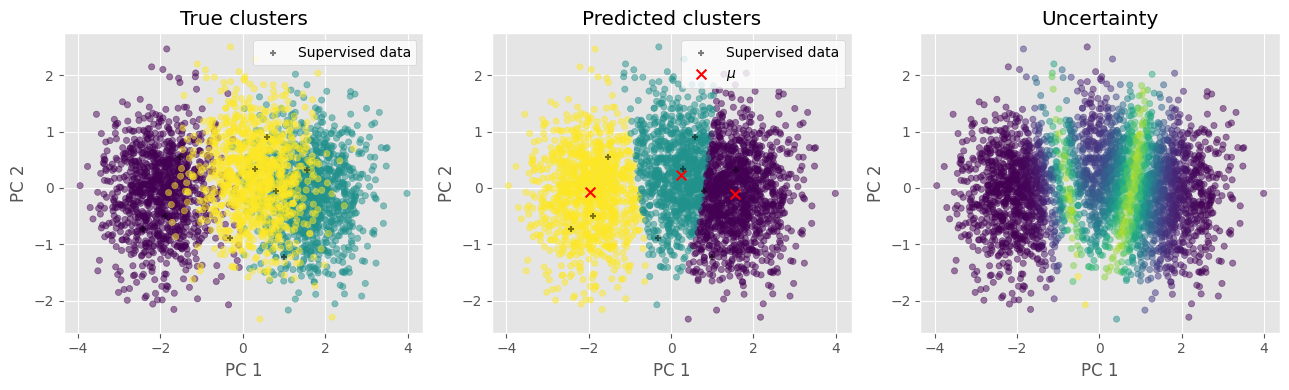

In [43]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=labels_gt,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### New data

In [44]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [45]:
new_mean = np.array([6, 1])
new_data = rng.multivariate_normal(mean=new_mean, cov=covs, size=(seq_length * 2))
new_data.shape

(2048, 2)

In [46]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [47]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(406, 20, 2)

In [48]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,699.672418,30.150600,98.802293,1.931840,-0.373340,0.874877,104.293648,6.215191,7.763663,-0.852305,...,0.0,0.0,0.0,1.0,4.271484,0.681718,-0.065278,0.115676,9.394265,0.775167
1,740.527670,29.931202,102.361034,1.855218,-0.400441,0.854870,111.374646,6.308006,7.390035,-0.656096,...,0.0,0.0,0.0,1.0,4.388789,0.581356,-0.343080,0.010064,-12.676184,0.780221
2,754.596287,24.457815,105.145926,1.749591,-0.386906,0.818849,113.391603,6.454712,7.785400,-0.152852,...,0.0,0.0,0.0,1.0,4.413202,0.651989,-0.539145,-0.258115,4.465815,0.794097
3,750.212554,20.828531,103.753963,1.871668,-0.363186,0.824397,110.914114,6.362477,6.355211,-0.213802,...,0.0,0.0,0.0,1.0,4.390447,0.883768,-0.550004,-0.175943,13.653546,0.773013
4,802.089290,19.403570,109.120998,1.890169,-0.331912,0.689658,125.040410,6.719251,5.602764,-0.787185,...,0.0,0.0,0.0,1.0,4.531812,0.741937,-0.310731,0.029918,8.519230,0.777642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,732.816111,24.611512,104.197050,1.978828,-0.247033,0.770682,109.879272,7.566131,5.113173,-0.619430,...,0.0,0.0,0.0,1.0,4.351516,0.649527,0.317332,0.788428,1.155425,0.780754
402,715.543769,23.077317,104.212392,1.913529,-0.235827,0.752479,105.991580,7.382610,5.864830,-0.860866,...,0.0,0.0,0.0,1.0,4.297153,0.675551,0.300224,0.676658,-10.109137,0.799337
403,718.216774,27.798219,103.042535,1.782118,-0.232100,0.904072,106.198735,7.106485,6.177259,-0.271414,...,0.0,0.0,0.0,1.0,4.318608,0.758286,0.562076,0.451598,-5.475665,0.789571
404,718.964026,28.433100,101.879089,1.827547,-0.256915,0.898276,105.623560,6.633465,6.478522,0.416088,...,0.0,0.0,0.0,1.0,4.322607,0.880889,0.845894,0.430475,10.467570,0.774891


In [49]:
new_feat_mat = pd.DataFrame(new_data)
new_feat_mat

,0,1
0,6.674087,0.680932
1,5.636124,0.520929
2,4.542986,1.910112
3,5.546297,0.433297
4,5.165634,0.855496
...,...,...
2043,6.978010,1.056107
2044,6.575088,1.716164
2045,6.188650,0.424068
2046,6.138104,1.853529


In [50]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [51]:
feat_mat_concat = pd.concat((feat_mat, new_feat_mat))
feat_mat_concat

,0,1
0,0.215468,2.264620
1,0.530649,3.665080
2,-1.379590,2.079220
3,0.090397,2.776383
4,-0.011880,2.396807
...,...,...
2043,6.978010,1.056107
2044,6.575088,1.716164
2045,6.188650,0.424068
2046,6.138104,1.853529


In [52]:
labels_gt_new = np.ones(new_data.shape[0]).astype(int) * 3
labels_gt_new

array([3, 3, 3, ..., 3, 3, 3], shape=(2048,))

In [53]:
labels_gt_concat = np.concat((labels_gt, labels_gt_new), axis=0)
labels_gt_concat

array([0, 0, 0, ..., 3, 3, 3], shape=(5120,))

In [54]:
gamma_resp, labels_pred, uncertainty, proba = predict(
    U=feat_mat_concat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    allow_singular=False,
    seed=seed,
)
gamma_resp, labels_pred, uncertainty, proba

(array([[8.28089750e-04, 3.29148598e-02, 9.66257050e-01],
        [2.88827022e-05, 1.44514962e-02, 9.85519621e-01],
        [6.67211448e-07, 1.81371886e-05, 9.99981196e-01],
        ...,
        [9.99998626e-01, 1.37416186e-06, 8.35501801e-17],
        [9.99979021e-01, 2.09788370e-05, 2.83846487e-14],
        [9.99995712e-01, 4.28777884e-06, 1.51017676e-15]], shape=(5120, 3)),
 array([2, 2, 2, ..., 0, 0, 0], shape=(5120,)),
 array([3.37429496e-02, 1.44803789e-02, 1.88044001e-05, ...,
        1.37416186e-06, 2.09788370e-05, 4.28777884e-06], shape=(5120,)),
 array([6.40410084e-02, 4.92995351e-02, 7.46426483e-03, ...,
        6.63927835e-06, 7.46843057e-06, 2.76304361e-06], shape=(5120,)))

In [55]:
# gamma_resp = e_step(
#     U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
# )

# N = U.shape[0]
# K = pi_mixing_prior.shape[0]
# proba = np.zeros((N, K))

# for k in range(K):
#     proba[:, k] = pi_mixing_prior[k]*multivariate_normal.pdf(
#         x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
#     )

In [56]:
proba.min(), proba.max(), proba.sum(), proba

(np.float64(9.398763498171403e-13),
 np.float64(0.13286987137119602),
 np.float64(212.87461080298644),
 array([6.40410084e-02, 4.92995351e-02, 7.46426483e-03, ...,
        6.63927835e-06, 7.46843057e-06, 2.76304361e-06], shape=(5120,)))

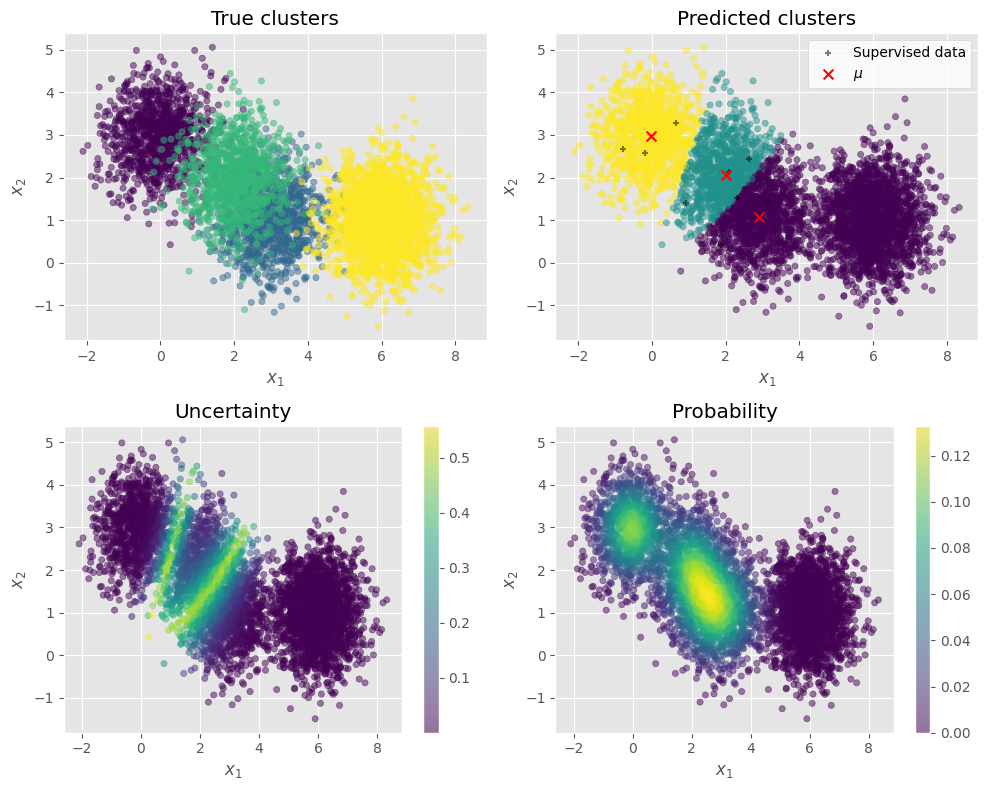

In [57]:
# # Transform data to first two principal components for plotting
# pca = PCA(n_components=2)
# U_pca = pca.fit_transform(new_feat_mat.to_numpy())
# X_pca = pca.transform(feat_mat.to_numpy())
# mu_pca = pca.transform(mu)

U = feat_mat_concat.to_numpy()


with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
    ax[0, 0].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_gt_concat)
    ax[0, 0].set_title("True clusters")
    ax[0, 1].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=labels_pred)
    ax[0, 1].scatter(
        X[:, 0],
        X[:, 1],
        marker="+",
        c="k",
        alpha=0.5,
        s=20,
        label="Supervised data",
    )
    ax[0, 1].scatter(
        mu[:, 0],
        mu[:, 1],
        marker="x",
        c="r",
        alpha=1,
        s=50,
        label=r"$\mu$",
    )
    ax[0, 1].set_title("Predicted clusters")
    scat_u = ax[1, 0].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=uncertainty)
    ax[1, 0].set_title("Uncertainty")
    fig.colorbar(scat_u, ax=ax[1, 0])
    scat_p = ax[1, 1].scatter(U[:, 0], U[:, 1], alpha=0.5, s=20, c=proba)
    ax[1, 1].set_title("Probability")
    fig.colorbar(scat_p, ax=ax[1, 1])
    for axi in ax.flatten():
        # axi.set_xlabel("PC 1")
        # axi.set_ylabel("PC 2")
        axi.set_xlabel(f"$x_1$")
        axi.set_ylabel(f"$x_2$")
    # for axi in ax[:2]:
    ax[0, 1].legend(loc="best", facecolor="white")
    fig.tight_layout()
    plt.show()

In [58]:
comp_i = 0
print(r"$\mu$: " + f"{mu[comp_i, :]}")
sampled_1 = rng.multivariate_normal(
    mean=mu[comp_i, :], cov=Sigma[comp_i, :, :], size=seq_length
)
sampled_1

$\mu$: [2.91137481 1.0769898 ]


array([[ 2.56002477,  0.92990391],
       [ 2.82118957,  1.03967349],
       [ 3.79855575, -0.62911202],
       ...,
       [ 2.95466536,  2.33485188],
       [ 1.3062261 ,  1.35111138],
       [ 2.35904979, -0.63550146]], shape=(1024, 2))

Iteration   0/300 -- Log-likelihood: -4430.24181293659

--- Converged at iteration 2 ---



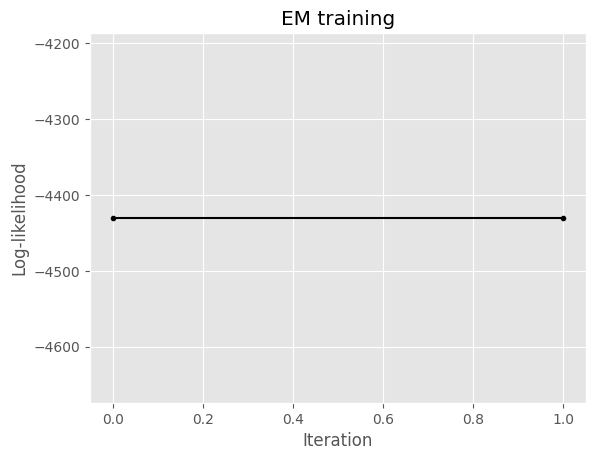

In [59]:
reg_coef = 1e-5
new_mu, new_Sigma, new_gamma_resp, new_clust_labels_pred, new_pi_mixing_prior = run_EM(
    K_components=1,
    U=new_feat_mat.to_numpy(),
    X=None,
    Y=None,
    beta=0,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [60]:
new_mu, new_Sigma, new_gamma_resp, new_clust_labels_pred, new_pi_mixing_prior

(array([[5.98973598, 0.98733345]]),
 array([[[0.49028886, 0.        ],
         [0.        , 0.5291167 ]]]),
 array([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(2048, 1)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([1.]))

In [61]:
sampled_2 = rng.multivariate_normal(
    mean=new_mu.squeeze(), cov=new_Sigma.squeeze(), size=seq_length
)
sampled_2

array([[ 7.28375139,  0.72508239],
       [ 6.54343497,  0.5101206 ],
       [ 5.9808456 ,  1.8592525 ],
       ...,
       [ 6.48174867,  2.00070197],
       [ 6.41411558,  0.93610706],
       [ 5.55889136, -0.50141035]], shape=(1024, 2))

In [62]:
hist_1, bins1 = np.histogram(sampled_1)
hist_2, bins2 = np.histogram(sampled_2)
hist_1, hist_2, bins1, bins2

(array([ 14,  75, 236, 378, 344, 363, 348, 218,  61,  11]),
 array([ 57, 340, 459, 156,  13,  14, 169, 492, 298,  50]),
 array([-1.19047842, -0.55014662,  0.09018517,  0.73051697,  1.37084876,
         2.01118056,  2.65151235,  3.29184415,  3.93217594,  4.57250774,
         5.21283953]),
 array([-1.07196248, -0.15386459,  0.76423331,  1.68233121,  2.60042911,
         3.518527  ,  4.4366249 ,  5.3547228 ,  6.2728207 ,  7.1909186 ,
         8.10901649]))

In [63]:
kl_divergence = kl_div(hist_1, hist_2)
kl_divergence

array([ 23.34408486, 151.64068719,  66.00845641, 112.5444352 ,
       795.83815117, 832.69041819,  72.36171017,  96.55156349,
       140.24060304,  22.34459494])

In [64]:
kl_divergence.mean()

np.float64(231.3564704672305)

In [65]:
sum(rel_entr(hist_1, hist_2))

np.float64(2313.5647046723047)

In [66]:
for comp_i in range(mu.shape[0]):
    print(r"$\mu$: " + f"{mu[comp_i, :]}")
    sampled_1 = rng.multivariate_normal(
        mean=mu[comp_i, :], cov=Sigma[comp_i, :, :], size=seq_length
    )

    hist_1, bins1 = np.histogram(sampled_1)
    hist_2, bins2 = np.histogram(sampled_2)
    kl_divergence = kl_div(hist_1, hist_2)
    print(f"KL div 1: {kl_divergence.mean()}")
    print(f"KL div 2: {sum(rel_entr(hist_1, hist_2))}")
    print("\n")

$\mu$: [2.91137481 1.0769898 ]
KL div 1: 215.8999687817123
KL div 2: 2158.999687817123


$\mu$: [1.99918775 2.05359819]
KL div 1: 363.4528988232531
KL div 2: 3634.5289882325305


$\mu$: [-0.03368987  2.97338991]
KL div 1: 114.84035229195608
KL div 2: 1148.4035229195606




In [67]:
# # Avoid division by zero or log of zero by adding a small epsilon
# eps = np.finfo(float).eps
# sampled_1[sampled_1 < eps] = eps
# sampled_1[sampled_1 == np.nan] = eps
# sampled_2[sampled_2 < eps] = eps
# sampled_2[sampled_2 == np.nan] = eps

# # Calculate KL Divergence
# kl_divergence_manual = np.sum(sampled_1 * np.log(sampled_1 / sampled_2))

# print(f"KL Divergence (Manual): {kl_divergence_manual:.4f}")

In [68]:
# def compute_KL(f, g):
#     """
#     Compute KL divergence KL(f, g) via numerical integration
#     """
#     def integrand(f, g):
#         # fw = f(w)
#         # gw = g(w)
#         return f * np.log(f / g)
#     val, _ = quad(integrand, 1e-5, 1-1e-5, f, g)
#     return val

# # Compute KL divergences between our example distributions
# kl_fg = compute_KL(sampled_1, sampled_2)
# kl_gf = compute_KL(sampled_2, sampled_1)

# print(f"KL(f, g) = {kl_fg:.4f}")
# print(f"KL(g, f) = {kl_gf:.4f}")

# Q
1. Matching Support: Both distributions P and Q must be defined over the same set of events or outcomes.
    - Binnerize & sort values? 
3. Jensen-Shannon divergence: Sometimes we want a symmetric measure of divergence that captures the difference between two distributions without favoring one over the other. This often arises in applications like **clustering**, where we want to compare distributions without assuming one is the true model.

## Lasa

In [69]:
# resample_num = 2**10
# print(f"Resampling to {resample_num} data points")
# smoothing_factor = 0

In [70]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [71]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
labels_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=seq_length, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        labels_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        labels_gt = np.hstack(
            (labels_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(labels_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": labels_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


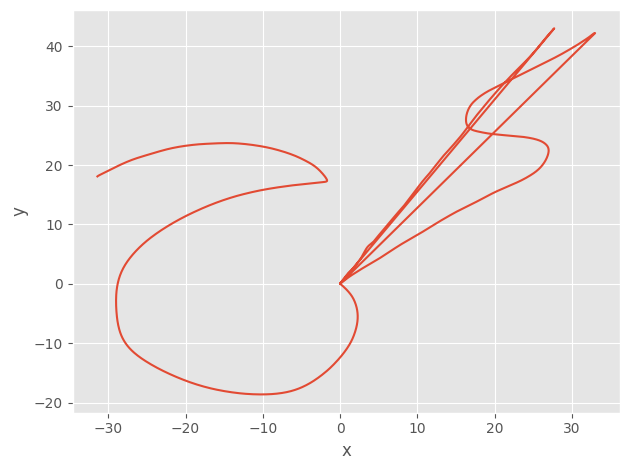

In [72]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

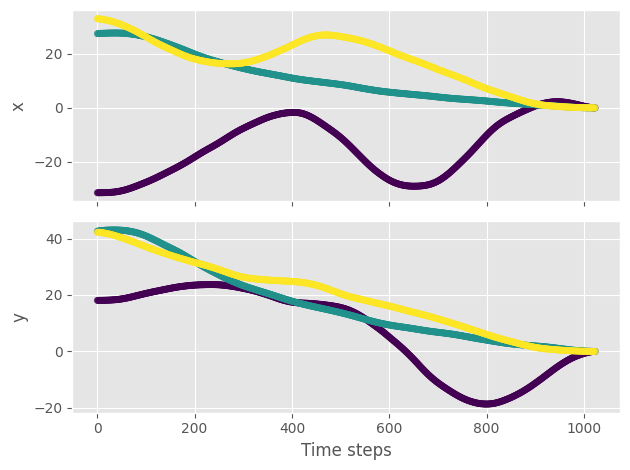

In [73]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [74]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [75]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [76]:
# windows = sliding_window(
#     series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
# )
# windows.shape

In [77]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(windows.shape[0]):
#         ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")
#     fig.tight_layout()
#     plt.show()

In [78]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
#     for idx in range(windows.shape[-1]):
#         for jdx in range(windows.shape[1]):
#             ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
#         ax[idx].set_ylabel(f"$x_{idx + 1}$")
#     ax[idx].set_xlabel("Time steps")
#     fig.tight_layout()
#     plt.show()

In [79]:
feat_mat, freeze_cols = features_augment(
    df=dataset[["pos_x", "pos_y"]], window_size=window_size, min_periods=window_step
)
feat_mat

,pos_x,pos_y,pos_x_roll_mean,pos_x_roll_max,pos_x_roll_min,pos_x_roll_std,pos_x_roll_quantile,pos_x_expand_mean,pos_x_expand_max,pos_x_expand_min,...,pos_y_roll_mean,pos_y_roll_max,pos_y_roll_min,pos_y_roll_std,pos_y_roll_quantile,pos_y_expand_mean,pos_y_expand_max,pos_y_expand_min,pos_y_expand_std,pos_y_expand_quantile
0,-31.414643,18.078238,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-31.414425,18.078527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-31.413891,18.079220,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,-31.413022,18.080319,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,-31.411800,18.081830,0.000000,0.000000,0.000000,0.000000,0.000000,-31.413556,-31.411800,-31.414643,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.079627,18.081830,18.078238,0.001469,18.078527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,0.001816,0.001816,0.029176,0.065896,0.001816,0.020541,0.011117,4.424778,33.018868,-31.414643,...,0.029176,0.065896,0.001816,0.020541,0.011117,14.368720,43.023192,-18.636448,14.807399,3.204984
3068,0.000857,0.000857,0.025924,0.061156,0.000857,0.019546,0.008529,4.423336,33.018868,-31.414643,...,0.025924,0.061156,0.000857,0.019546,0.008529,14.364039,43.023192,-18.636448,14.807257,3.196323
3069,0.000250,0.000250,0.022879,0.056577,0.000250,0.018483,0.006277,4.421895,33.018868,-31.414643,...,0.022879,0.056577,0.000250,0.018483,0.006277,14.359360,43.023192,-18.636448,14.807114,3.179043
3070,-0.000002,-0.000002,0.020050,0.052160,-0.000002,0.017349,0.004366,4.420456,33.018868,-31.414643,...,0.020050,0.052160,-0.000002,0.017349,0.004366,14.354684,43.023192,-18.636448,14.806970,3.171572


In [80]:
# feat_mat = extract_features(windows)
# feat_mat.shape

In [81]:
# for col in range(feat_mat.shape[1]):
#     if np.any(np.isnan(feat_mat[:, col])):
#         feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

In [82]:
# y_cls_win = np.round(
#     np.mean(
#         sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
#         axis=1,
#         dtype=int,
#     )
# )

In [83]:
K_components = len(datasets)
K_components

3

In [84]:
supervised_sample_size = 50
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    # labels_gt=y_cls_win,
    labels_gt=dataset.y_cls,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((51, 22),
 array([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1]]))

In [85]:
# supervised_sample_size = 50
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [86]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [87]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

Iteration   0/300 -- Log-likelihood: -114650.1251299075
Iteration  10/300 -- Log-likelihood: -113947.13678546586
Iteration  20/300 -- Log-likelihood: -113911.99236474867
Iteration  30/300 -- Log-likelihood: -113909.16921761424
Iteration  40/300 -- Log-likelihood: -113908.93235101781

--- Converged at iteration 49 ---



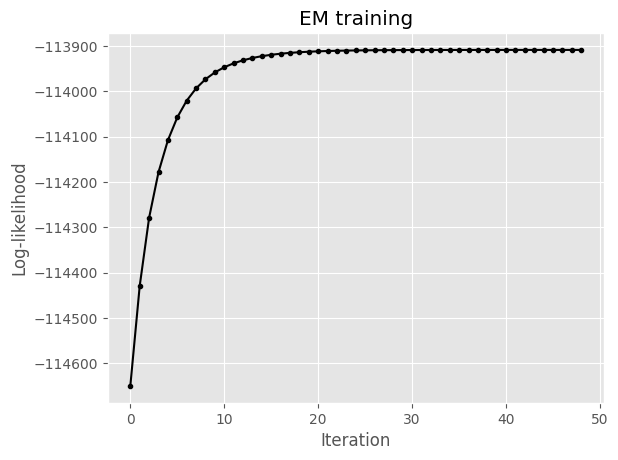

In [88]:
reg_coef = 5e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [89]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 19.63218015,  25.74196139,  19.49808565,  20.39603605,
          18.59769531,   0.65383187,  19.04807708,  -1.74805761,
          30.43839792, -31.00621527,  16.99921033, -14.43370494,
          25.5861545 ,  26.66558434,  24.50289658,   0.80529541,
          25.04542057,  13.54103061,  42.46043179, -18.39415231,
          16.25155779,   0.772447  ],
        [  2.10933365,   1.40659451,   2.32838373,   2.64665494,
           2.00391111,   0.20044185,   2.16809061,  -3.39708885,
          22.75117195, -30.87562405,  15.24151924, -15.06731688,
           1.36137879,   1.75070849,   0.97837711,   0.24080781,
           1.16745358,  12.45073926,  38.06410596, -18.21427654,
          15.06353966,   1.96836488],
        [-16.92459574,  11.75033405, -16.60008486, -15.68212774,
         -17.50485913,   0.56839259, -17.05729257, -21.00683657,
          -8.0369754 , -32.5574799 ,   8.1194129 , -28.64782932,
          11.8726378 ,  12.45572672,  11.28946024,   0.36357467,
          11.5

In [90]:
# y_cls_win, clust_labels_pred
dataset.y_cls.to_numpy(), clust_labels_pred

(array([0, 0, 0, ..., 2, 2, 2], shape=(3072,)),
 array([1, 1, 1, ..., 1, 1, 1], shape=(3072,)))

In [91]:
# print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)
print_metrics(X=feat_mat, labels_true=dataset.y_cls, labels_pred=clust_labels_pred)

Silhouette: 0.47064976642535195
Completeness: 0.4509725010007518
Fowlkes-Mallows index: 0.5835549179822663
Homogeneity: 0.4432231086731831
Mutual Information: 0.48693035381004013
Adjusted mutual information: 0.4467332163378303
Normalized Mutual Information: 0.44706422544964053
Rand index: 0.7171593892461738
Adjusted rand index: 0.3694537256137652
V-measure: 0.4470642254496405


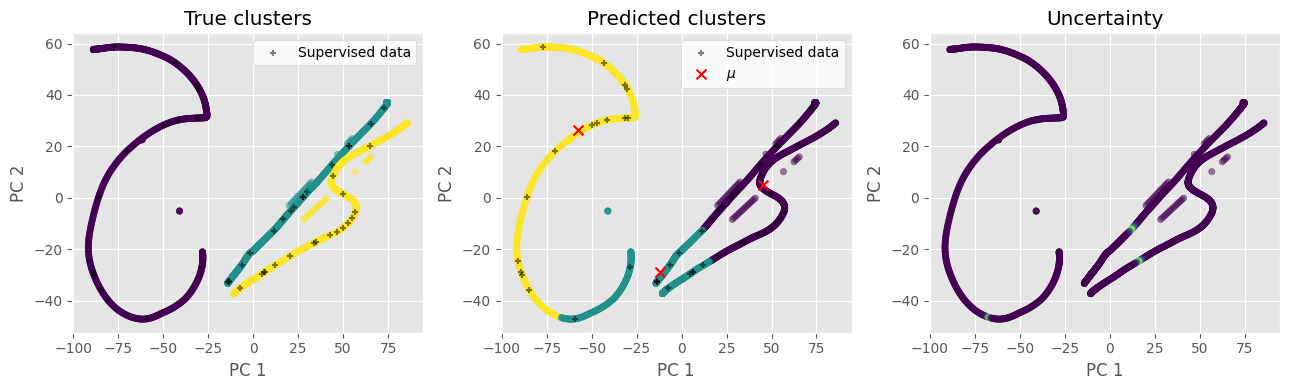

In [92]:
plot_cluster_res3(
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=dataset.y_cls,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## Synthetic hierarchical (toy) data

In [93]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [94]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [95]:
n_meta = 3
n_sub = 4
obs_dim = 5

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            m * 15 + s * 2.5,
            m * 20 + s * 1,
            m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            # covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [3.0, 0.8, 0.8, 0.0, 0.0],
                    [0.8, 3.0, 0.8, 0.0, 0.0],
                    [0.0, 0.8, 2.0, 0.8, 0.0],
                    [0.0, 0.0, 0.8, 2.0, 0.8],
                    [0.0, 0.0, 0.8, 0.8, 2.0],
                ]
            ) * (s + 1)
        else:  # Meta 2: anti-correlated
            # covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)
            covariances[m, s] = np.array(
                [
                    [2.0, -0.5, -0.5, 0.0, 0.0],
                    [-0.5, 2.0, -0.5, 0.0, 0.0],
                    [0.0, -0.5, 1.0, -0.5, 0.0],
                    [0.0, 0.0, -0.5, 1.0, -0.5],
                    [0.0, 0.0, -0.5, -0.5, 1.0],
                ]
            ) * (s + 1)
        covariances[m, s] = 1 / 2 * (covariances[m, s] + covariances[m, s].T)

In [96]:
# covariances

In [97]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 2 2 ... 0 0 0]
Sub states:   [2 2 2 ... 2 3 2]
Observations:
[[22.94 15.56 37.2  37.97  1.64]
 [23.81 10.08 36.85 42.68 -0.74]
 [24.43 14.29 33.52 43.96 -1.38]
 [26.93 14.38 36.46 43.22  1.24]
 [ 8.87  1.73 14.71 19.51  1.07]
 [11.57  7.94 20.61 22.42  0.58]
 [12.32  8.91 20.87 20.52 -0.83]
 [ 5.09  0.48  4.45  1.19 -1.11]
 [ 0.78  2.87  0.12  0.53  0.23]
 [ 3.12  1.01  1.85  2.21 -0.27]]
 [...]


In [98]:
observations.shape

(1024, 5)

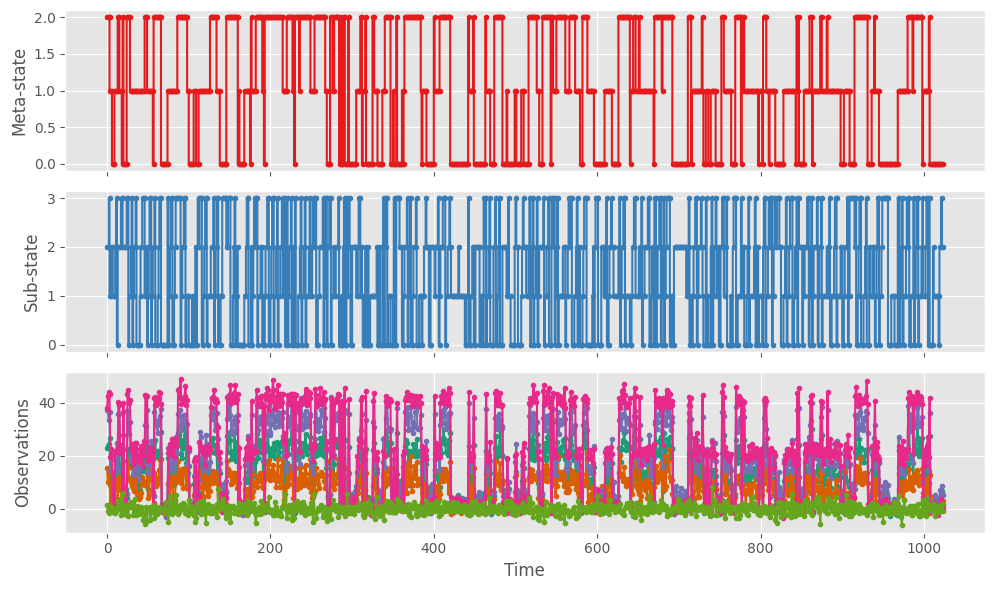

In [99]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    cmap2 = plt.colormaps["Dark2"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    for obsi in range(obs_dim):
        axes[2].plot(observations[:, obsi], ".-", c=cmap2[obsi])  # , c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

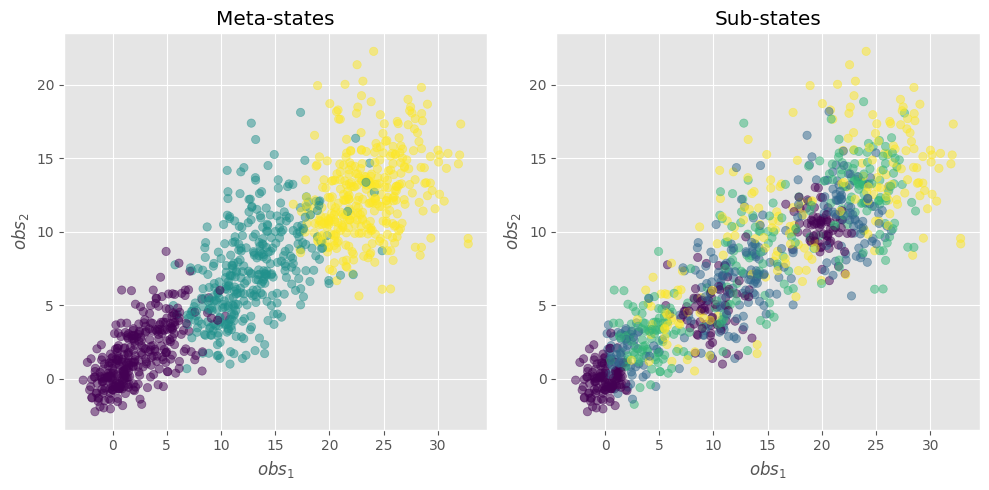

In [100]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [101]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(201, 20, 5)

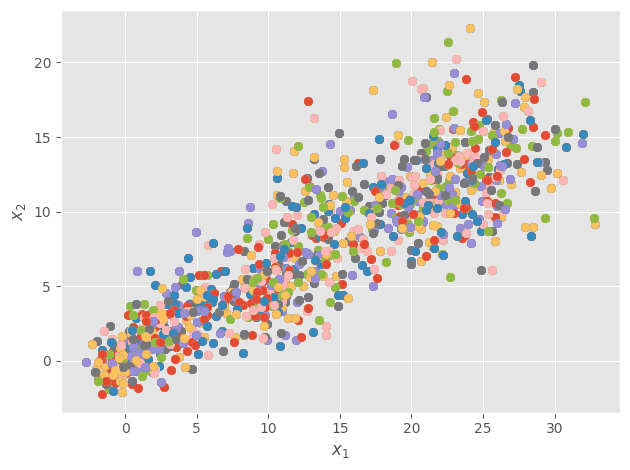

In [102]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

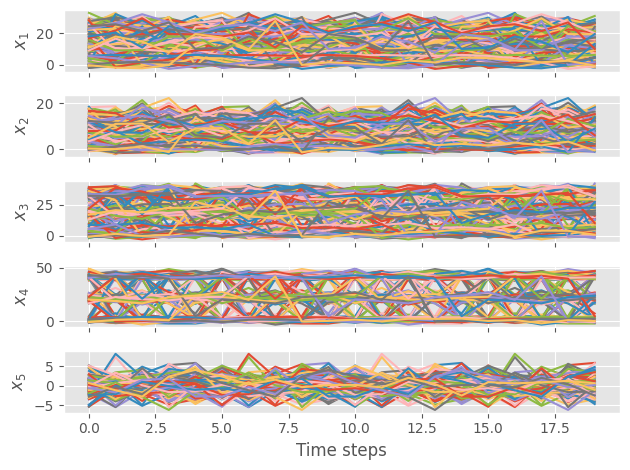

In [103]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [104]:
feat_mat = extract_features(windows)
feat_mat.shape

(201, 69)

In [105]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,5309.710880,1715.018059,11995.584216,15009.528201,99.346315,926.786575,0.763659,0.953137,0.790478,0.812107,...,1.0,18.474087,0.457070,-0.044619,-0.243340,-0.238790,-0.114295,1.016047,-63.086589,0.898502
1,3737.859604,1061.485940,8046.610227,9164.488927,103.868960,702.664741,1.956361,0.921991,0.740627,0.815052,...,1.0,14.870882,0.596520,0.603298,-0.147804,0.314613,0.256456,0.998356,2062.489192,1.041180
2,5512.416626,1830.360341,12112.166002,15990.933899,116.742594,952.718338,1.540105,0.953048,0.821130,0.594904,...,1.0,18.858054,0.655690,-0.089075,0.133048,-0.106546,-0.245232,0.535868,768.821665,0.903935
3,5230.394457,1825.601860,11051.883604,14817.065776,132.659682,898.645211,2.187019,0.951371,0.816080,0.637961,...,1.0,18.181751,0.600253,0.019980,0.166791,0.054384,-0.131839,0.340255,1300.382054,0.900477
4,4749.216609,1953.930971,9733.344807,13813.028578,65.516572,879.352565,2.124440,0.846356,0.869614,0.915605,...,1.0,17.411214,0.591098,0.322749,0.366168,0.334436,-0.029713,0.137564,-3563.590573,0.916103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,10070.319290,2494.485312,20670.526910,30171.287946,62.409742,1521.790478,4.238987,0.683141,0.755358,0.241180,...,1.0,25.193060,0.443644,-0.462079,-0.109925,-1.688856,-2.550199,0.201685,2084.714470,0.737257
197,8803.136285,2295.040792,17770.070680,24832.797736,90.975950,1342.956083,4.022200,0.775391,0.809935,0.397912,...,1.0,23.193107,0.552565,-0.348397,-0.692503,-0.724875,-1.020051,0.431842,-8479.518897,0.767653
198,8076.830221,2029.395540,14849.176584,20402.606375,86.408889,1154.530959,2.861276,0.847304,0.852912,0.477664,...,1.0,21.317696,0.562651,-0.558741,-0.883454,-0.902381,-0.684270,0.021759,-11239.734975,0.874584
199,4762.422250,1313.896513,8709.361931,11851.865773,80.860141,762.995587,1.515522,0.877824,0.873732,0.742524,...,1.0,16.345766,0.456017,0.213905,0.075601,0.049485,0.312743,0.001929,-4324.892962,1.144158


In [106]:
feat_mat = pd.DataFrame(observations)
feat_mat

,0,1,2,3,4
0,22.940814,15.556814,37.197462,37.966697,1.637203
1,23.811693,10.079408,36.853285,42.682567,-0.740727
2,24.425144,14.285568,33.523082,43.963736,-1.384405
3,26.930447,14.382339,36.462963,43.223479,1.238360
4,8.872408,1.733691,14.711358,19.505542,1.071051
...,...,...,...,...,...
1019,-0.693081,-0.635234,0.837853,-0.042147,-1.046182
1020,3.052952,3.572248,7.147235,-0.267124,-0.078180
1021,6.146288,0.697322,5.986919,3.786652,-0.322815
1022,6.689634,5.664705,8.622561,1.036055,1.980533


### Meta-states clustering

In [107]:
K_components = n_meta

In [108]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2,
       1, 1, 0])

In [109]:
# supervised_sample_size = 20
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [110]:
supervised_sample_size = 15
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((15, 5),
 array([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1]]))

Iteration   0/300 -- Log-likelihood: -8009.149570496394

--- Converged at iteration 5 ---



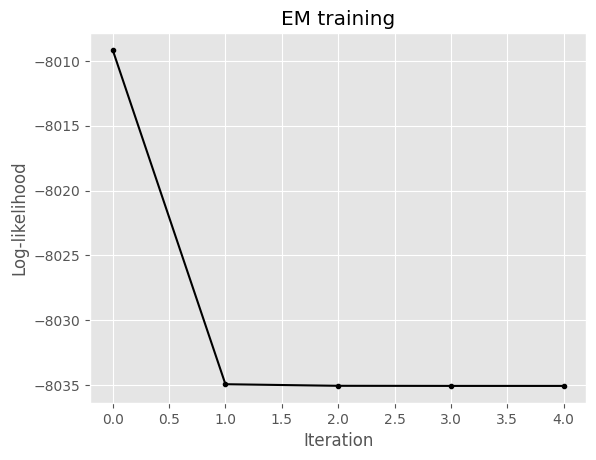

In [111]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [112]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[23.40064753, 12.5264197 , 33.96523513, 41.50027038, -0.19998087],
        [13.0184033 ,  7.48249855, 19.03543584, 21.6724872 ,  0.06964321],
        [ 2.54918761,  1.809998  ,  3.28989469,  1.44388005,  0.12794494]]),
 array([[[10.08061421,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  8.25363374,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  9.91586443,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  4.2987051 ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           2.50590687]],
 
        [[11.88849776,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        , 10.23186156,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 13.53082174,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  5.56210192,
           0.       

In [113]:
y_cls_win, clust_labels_pred

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2,
        1, 1, 0]),
 array([0, 0, 0, ..., 2, 2, 2], shape=(1024,)))

In [114]:
# print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)
print_metrics(X=feat_mat, labels_true=meta_states, labels_pred=clust_labels_pred)

Silhouette: 0.7089622162144964
Completeness: 1.0
Fowlkes-Mallows index: 1.0
Homogeneity: 1.0
Mutual Information: 1.097173023671596
Adjusted mutual information: 1.0
Normalized Mutual Information: 1.0
Rand index: 1.0
Adjusted rand index: 1.0
V-measure: 1.0


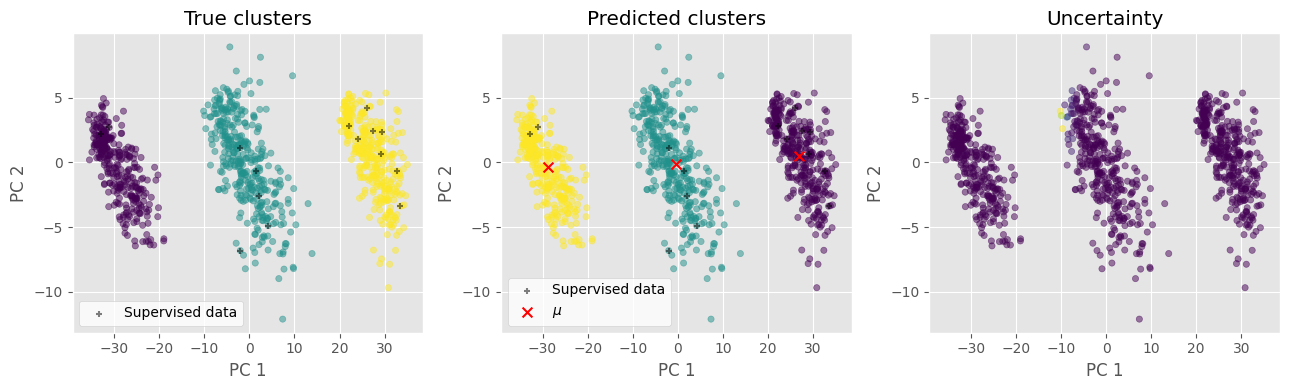

In [115]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=meta_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### Sub-states clustering

In [116]:
K_components = n_sub

In [117]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 1, 1])

In [118]:
# supervised_sample_size = 30
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = labels_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [119]:
supervised_sample_size = 30
X, Y, _ = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((30, 5),
 array([[0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0]]))

Iteration   0/300 -- Log-likelihood: -9987.310346222954
Iteration  10/300 -- Log-likelihood: -10195.746897281973
Iteration  20/300 -- Log-likelihood: -10261.150416903685
Iteration  30/300 -- Log-likelihood: -10271.811523339571
Iteration  40/300 -- Log-likelihood: -10273.461469223637
Iteration  50/300 -- Log-likelihood: -10270.95776363257
Iteration  60/300 -- Log-likelihood: -10252.1407516488
Iteration  70/300 -- Log-likelihood: -9919.560441935628
Iteration  80/300 -- Log-likelihood: -9586.27767730632
Iteration  90/300 -- Log-likelihood: -9578.950251177615
Iteration 100/300 -- Log-likelihood: -9578.442084531682
Iteration 110/300 -- Log-likelihood: -9578.425187976423
Iteration 120/300 -- Log-likelihood: -9578.42599909297
Iteration 130/300 -- Log-likelihood: -9578.426131224143

--- Converged at iteration 135 ---



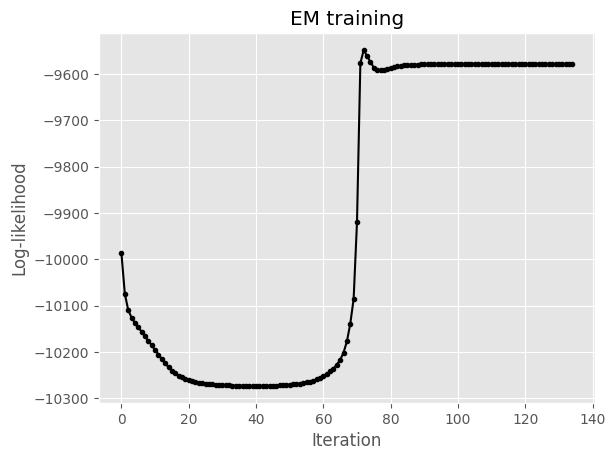

In [120]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [121]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[23.99659244, 12.86323179, 34.92796668, 42.63366875, -0.20887903],
        [ 1.86410057,  1.26221428,  2.50611926,  1.35474827,  0.09822786],
        [ 3.17046499,  2.18530223,  4.15910894,  2.29785749,  0.10396288],
        [13.42526742,  7.71812724, 19.55972322, 22.16787494,  0.0815746 ]]),
 array([[[10.50109109,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  8.46479326,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 10.73267461,  0.        ,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  5.27093041,
           0.        ],
         [ 0.        ,  0.        ,  0.        ,  0.        ,
           2.54188048]],
 
        [[27.91767798,  0.        ,  0.        ,  0.        ,
           0.        ],
         [ 0.        , 10.35189929,  0.        ,  0.        ,
           0.        ],
         [ 0.        ,  0.        , 57.86771253,  0.        ,
           0.        ],
       

In [122]:
# print_metrics(X=feat_mat, labels_true=y_cls_win, labels_pred=clust_labels_pred)
print_metrics(X=feat_mat, labels_true=sub_states, labels_pred=clust_labels_pred)

Silhouette: 0.5342180503688465
Completeness: 0.09327884573013073
Fowlkes-Mallows index: 0.29965507391348395
Homogeneity: 0.0872496635372304
Mutual Information: 0.12051568693959311
Adjusted mutual information: 0.08714580882417429
Normalized Mutual Information: 0.09016357513972498
Rand index: 0.6192379948680352
Adjusted rand index: 0.039422893229911396
V-measure: 0.09016357513972498


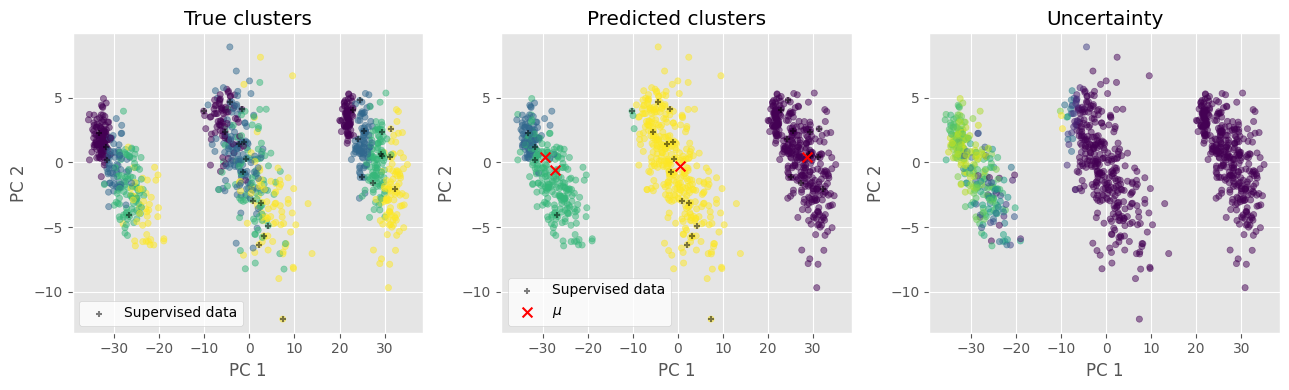

In [123]:
plot_cluster_res3(
    U=feat_mat,
    X=X,
    Y=Y,
    # labels_gt=y_cls_win,
    labels_gt=sub_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## IROS data

In [124]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path("..") / "sdl" / "data"
assert data_path_root.exists(), "Data path doesn't exist"

In [125]:
ground_truth_segm_file = data_path_root.parent / "segm_ground_truth.json"
assert ground_truth_segm_file.exists(), "Ground truth file not found"

In [126]:
def plot_xyzgrip(traj, supervised_samples=None):
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(traj.columns) - 1,
            ncols=1,
            sharex=True,  # figsize=(8, 5)
        )
        # cmap = mpl.colormaps.get("tab10").colors
        jdx = 0
        for idx, axi in enumerate(range(len(traj.columns))):
            if traj.columns[idx] == "timestamp":
                continue
            ax[jdx].plot(
                traj.timestamp, traj[traj.columns[idx]], color="k"
            )  # cmap[idx])
            ax[jdx].set_ylabel(traj.columns[idx])
            # if supervised_samples is not None:
            #     ax[jdx].scatter(
            #         traj.timestamp, supervised_samples[:, idx]#, color="k"
            #     )  # cmap[idx])
            jdx += 1
        ax[-1].set_xlabel("Time")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [127]:
def smooth_traj(traj, nb_points=256, smoothing_factor=0):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col], s=smoothing_factor)(
                        new_index
                    ),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col], s=smoothing_factor)(
                new_index
            )
    return traj_smooth

In [128]:
def preprocessing(traj, resample_num):
    traj_float = traj.drop(columns=["timestamp"])
    traj_down = smooth_traj(traj=traj_float, nb_points=resample_num)
    # plot_processed_traj(X_down=X_down)
    minmaxscaler = MinMaxScaler(feature_range=(0, 1))
    traj_down_scaled = minmaxscaler.fit_transform(traj_down)
    return traj_down, minmaxscaler, traj_down_scaled

In [129]:
def plot_supervised_data(
    traj, supervised_samples, idx_superv, segments_num
):  # true_labels
    ts = np.arange(traj_all.shape[0])
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(traj.columns),  # - 1,
            ncols=1,
            sharex=True,
            figsize=(8, len(traj.columns)),  # - 1),
        )
        cmap = mpl.colormaps.get("tab10").colors
        jdx = 0
        for idx, axi in enumerate(range(len(traj.columns))):
            if traj.columns[idx] == "label_true":
                continue
            # for label_i, label_v in enumerate(traj.label_true.unique()):
            # for label_i, label_v in enumerate(np.unique(true_labels)):
            #     ax[jdx].plot(
            #         # ts[traj.label_true == label_i],
            #         ts[true_labels == label_i],
            #         # traj[traj.columns[idx]][traj.label_true == label_i],
            #         traj[traj.columns[idx]][true_labels == label_i],
            #         color=cmap[label_i],
            #     )
            for segm_i, segm_v in enumerate(segments_num.columns):
                ax[jdx].plot(
                    ts[segments_num[segm_v] == 1],
                    traj[traj.columns[idx]][segments_num[segm_v] == 1],
                    color=cmap[segm_i % len(cmap)],
                )

            ax[jdx].set_ylabel(traj.columns[idx].replace("_", "\n"))
            ax[jdx].scatter(
                ts[idx_superv],
                supervised_samples[:, jdx],
                marker="o",
                facecolors="none",
                edgecolors="k",
                zorder=3,
            )
            jdx += 1
        ax[-1].set_xlabel("Time steps")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [130]:
def resample_array(array, nb_points=256, smoothing_factor=1e-3):
    ori_index = np.arange(array.shape[0])
    new_index = np.linspace(start=0, stop=array.shape[0], num=nb_points)
    arr_resampled = np.ones((nb_points, array.shape[1])) * np.nan
    for colidx, _ in enumerate(range(array.shape[1])):
        arr_resampled[:, colidx] = make_splrep(
            ori_index, array[:, colidx], s=smoothing_factor
        )(new_index)
    return arr_resampled

In [131]:
def get_segm_gt(gt_segm_dict, traj, resample_num, smoothing_factor, task_sequence=None):

    # Create unique labels names for each segments
    nsegments = 0
    segm_labels = []
    for segm_key, segm_val in gt_segm_dict["segments"].items():
        if isinstance(segm_val, list):
            nsegments += len(segm_val)
            for jdx, _ in enumerate(segm_val):
                segm_labels.append(f"{segm_key}_{jdx + 1}")
        elif isinstance(segm_val, dict):
            nsegments += 1
            segm_labels.append(f"{segm_key}")
        else:
            raise ValueError("Unexpected value in ground truth JSON file")
    print(f"Number of segments: {nsegments}")
    print(f"Segments labels: {segm_labels}")

    # Create the activations matrix for each segments
    segments = np.zeros((traj.shape[0], nsegments)).astype(int)
    col_i = 0
    for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
        sect_dict_current = gt_segm_dict["segments"][sect_key]
        if isinstance(sect_dict_current, list):
            for sect_j, sect_cur in enumerate(sect_dict_current):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(sect_cur["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(sect_cur["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]
                segments[xs.index, col_i] = np.ones_like(xs)
                col_i += 1

        elif isinstance(sect_dict_current, dict):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_dict_current["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            segments[xs.index, col_i] = np.ones_like(xs)
            col_i += 1
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

    if task_sequence:
        task_matrix = np.zeros((traj.shape[0], len(task_sequence.keys()))).astype(int)
        for key_meta_i, key_meta_v in enumerate(task_sequence.keys()):
            for key_sub in task_sequence[key_meta_v]:
                task_matrix[:, key_meta_i] += pd.DataFrame(
                    segments, columns=segm_labels
                )[key_sub]

    # Plot the activation functions
    with plt.style.context("ggplot"):
        cmap = mpl.colormaps.get("Set2").colors
        fig, ax = plt.subplots(figsize=(11, 5))
        for idx in range(segments.shape[1]):
            ax.plot(
                traj.timestamp,
                segments[:, idx],
                # label=segm_labels[idx],
                color="k",
                # linewidth=1.5,
            )
        ax.stackplot(
            traj.timestamp,
            segments.T,
            labels=segm_labels,
            alpha=0.6,
            colors=cmap,
        )
        ax.set_xlabel("Time")
        ax.set_ylabel("Activation functions")

        ax.plot(traj.timestamp, traj.pos_x, label="x")  # , color=cmap[0])
        ax.plot(traj.timestamp, traj.pos_y, label="y")  # , color=cmap[1])
        ax.plot(traj.timestamp, traj.pos_z, label="z")  # , color=cmap[2])
        ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])

        # ax.legend(loc="best")
        ax.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

    # Resample
    segments_down = np.round(
        resample_array(
            array=segments, nb_points=resample_num, smoothing_factor=smoothing_factor
        )
    ).astype(int)  # Round to make sure it's either zero or one
    segments_df = pd.DataFrame(segments_down, columns=segm_labels)
    if task_sequence:
        task_matrix_down = np.round(
            resample_array(
                array=task_matrix,
                nb_points=resample_num,
                smoothing_factor=smoothing_factor,
            )
        ).astype(int)  # Round to make sure it's either zero or one
        task_matrix_df = pd.DataFrame(task_matrix_down, columns=task_sequence.keys())

    # Create a single column vector out of the segment matrix
    if task_sequence:
        true_labels = np.ones(task_matrix_down.shape[0]).astype(int) * np.nan
        for label_i, label_v in enumerate(task_sequence.keys()):
            for col_i, col_val in enumerate(task_matrix_df.columns):
                if label_v in col_val:
                    true_labels[task_matrix_df.iloc[:, col_i] == 1] = label_i
    else:
        true_labels = np.ones(segments_down.shape[0]).astype(int) * np.nan
        for label_i, label_v in enumerate(gt_segm_dict["segments"].keys()):
            for col_i, col_val in enumerate(segments_df.columns):
                if label_v in col_val:
                    true_labels[segments_df.iloc[:, col_i] == 1] = label_i

    if task_sequence:
        return true_labels, task_matrix_df
    else:
        return true_labels, segments_df

In [132]:
task_sequence = OrderedDict(
    [
        (
            "open-drawer-full",
            ["reaching_1", "grasping_1", "open-drawer", "releasing_1"],
        ),
        ("pick-and-place1", ["reaching_2", "grasping_2", "placing_1", "releasing_2"]),
        ("pick-and-place2", ["reaching_3", "grasping_3", "placing_2", "releasing_3"]),
        (
            "close-drawer-full",
            ["reaching_4", "grasping_4", "close-drawer", "releasing_4"],
        ),
        ("pick-and-pour", ["reaching_5", "grasping_5", "pouring", "releasing_5"]),
    ]
)

In [133]:
# filenums = [2, 4]  # Subtasks
# K_components = len(filenums)
filenums = [0]  # Long task
K_components = len(task_sequence)

supervised_sample_size = 100

{'hdf5': 'long-task-1.h5',
 'segments': {'close-drawer': {'end': 1769723276, 'ini': 1769723270},
              'grasping': [{'end': 1769723226, 'ini': 1769723222},
                           {'end': 1769723239, 'ini': 1769723237},
                           {'end': 1769723253, 'ini': 1769723251},
                           {'end': 1769723270, 'ini': 1769723267},
                           {'end': 1769723296, 'ini': 1769723288}],
              'open-drawer': {'end': 1769723231, 'ini': 1769723226},
              'placing': [{'end': 1769723245, 'ini': 1769723239},
                          {'end': 1769723258, 'ini': 1769723253}],
              'pouring': {'end': 1769723309, 'ini': 1769723296},
              'reaching': [{'end': 1769723222, 'ini': 1769723215},
                           {'end': 1769723237, 'ini': 1769723234},
                           {'end': 1769723251, 'ini': 1769723248},
                           {'end': 1769723267, 'ini': 1769723262},
                           {'end

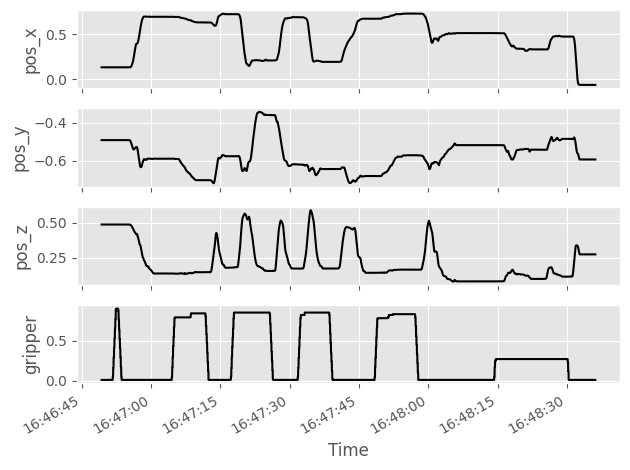

Number of segments: 20
Segments labels: ['reaching_1', 'reaching_2', 'reaching_3', 'reaching_4', 'reaching_5', 'open-drawer', 'grasping_1', 'grasping_2', 'grasping_3', 'grasping_4', 'grasping_5', 'placing_1', 'placing_2', 'releasing_1', 'releasing_2', 'releasing_3', 'releasing_4', 'releasing_5', 'close-drawer', 'pouring']


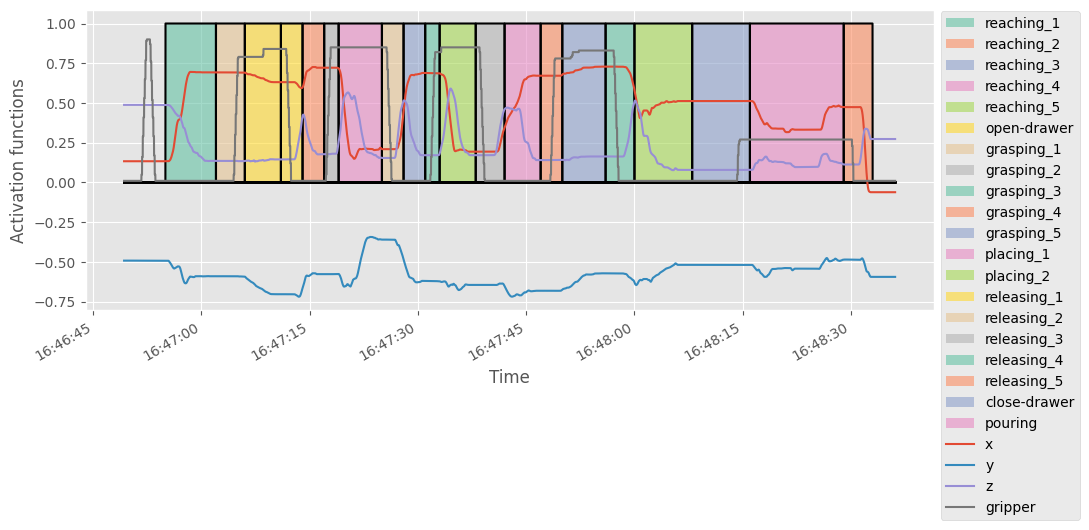

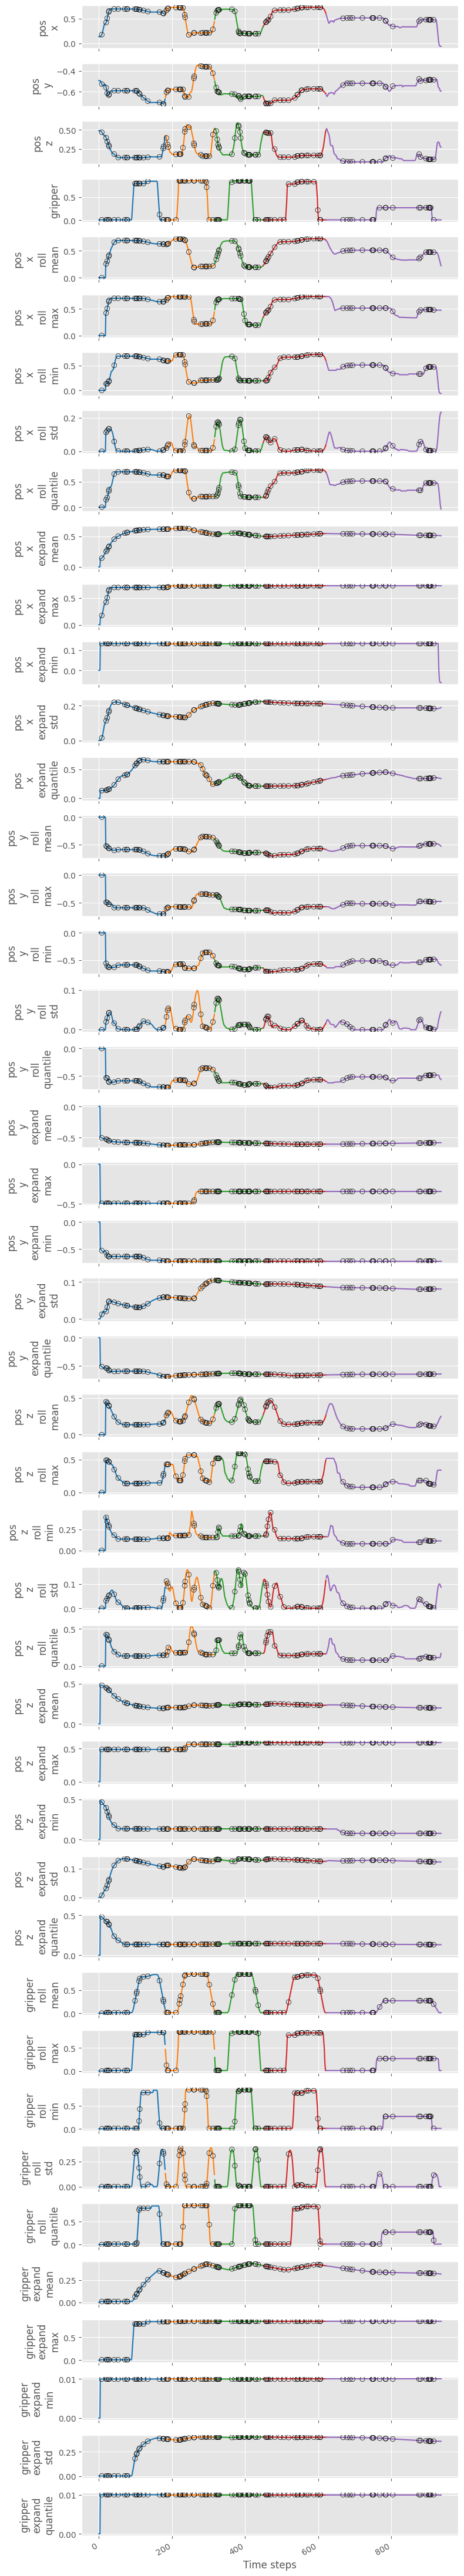

In [134]:
traj_all = []
true_labels = []
segments_num = []
for file_i, file_val in enumerate(filenums):
    gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
        ground_truth_segm_file=ground_truth_segm_file, filenum=file_val
    )
    pprint(gt_segm_dict)
    hdf5_path = data_path_root / hdf5_file
    video_path = data_path_root / video_file
    joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)
    traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
    plot_xyzgrip(traj=traj)  # , supervised_data=X)
    traj_down, minmaxscaler, traj_down_scaled = preprocessing(
        traj=traj, resample_num=seq_length
    )  # <--- Q: Scale or not scale?

    # Ground truth labels
    # true_labels.append([gt_segm_dict["hdf5"].replace(".h5", "") for item in range(seq_length)])
    # true_labels.append([file_i for item in range(seq_length)])
    true_lab, segments_df = get_segm_gt(
        gt_segm_dict=gt_segm_dict,
        traj=traj,
        resample_num=seq_length,
        smoothing_factor=smoothing_factor,
        task_sequence=task_sequence,
        # task_sequence=None,
    )
    true_labels.append(true_lab)
    segments_num.append(segments_df)

    traj_all.append(traj_down)

true_labels = np.concat(true_labels)
traj_all = pd.concat(traj_all)
segments_num = pd.concat(segments_num)

# Remove points before/after demonstration
idx_ini = np.min(np.argwhere(~np.isnan(true_labels)))
idx_end = np.max(np.argwhere(~np.isnan(true_labels)))
true_labels = true_labels[idx_ini:idx_end].astype(int)
traj_all = traj_all[idx_ini:idx_end]
segments_num = segments_num[idx_ini:idx_end]

traj_all, freeze_cols = features_augment(
    df=traj_all, window_size=window_size, min_periods=window_step
)
U = traj_all.to_numpy()  # .drop(columns=["label_true"]).to_numpy()

X, Y, idx_superv = select_supervised_data(
    total_sample_size=supervised_sample_size,
    # labels_gt=traj_all.label_true.to_numpy(),
    labels_gt=true_labels,
    K_components=K_components,
    U=U,
)
plot_supervised_data(
    traj=traj_all,
    supervised_samples=X,
    idx_superv=idx_superv,
    segments_num=segments_num,
)  # true_labels=true_labels)

In [135]:
np.unique(true_labels)

array([0, 1, 2, 3, 4])

In [136]:
np.any(np.isnan(true_labels))

np.False_

In [137]:
traj_all

,pos_x,pos_y,pos_z,gripper,pos_x_roll_mean,pos_x_roll_max,pos_x_roll_min,pos_x_roll_std,pos_x_roll_quantile,pos_x_expand_mean,...,gripper_roll_mean,gripper_roll_max,gripper_roll_min,gripper_roll_std,gripper_roll_quantile,gripper_expand_mean,gripper_expand_max,gripper_expand_min,gripper_expand_std,gripper_expand_quantile
56,0.133473,-0.491963,0.488024,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
57,0.133485,-0.491974,0.488008,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
58,0.133502,-0.491991,0.487968,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
59,0.133554,-0.492520,0.487351,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
60,0.134575,-0.496435,0.485776,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.133718,...,0.00,0.00,0.00,0.000000e+00,0.00,0.010000,0.010000,0.010000,1.226635e-18,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,-0.052664,-0.571185,0.313422,0.01,0.330115,0.474315,-0.052664,0.196670,0.196688,0.509632,...,0.01,0.01,0.01,1.319927e-18,0.01,0.317312,0.850002,0.009995,3.581395e-01,0.01
989,-0.058468,-0.583014,0.293217,0.01,0.303498,0.474315,-0.058468,0.211644,0.117819,0.509024,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316983,0.850002,0.009995,3.580888e-01,0.01
990,-0.060766,-0.591810,0.277531,0.01,0.276768,0.474315,-0.060766,0.222480,0.049065,0.508414,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316655,0.850002,0.009995,3.580378e-01,0.01
991,-0.061517,-0.594205,0.273142,0.01,0.249998,0.474315,-0.061517,0.229611,-0.004124,0.507805,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316327,0.850002,0.009995,3.579866e-01,0.01


In [138]:
pd.DataFrame(U)

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,0.133473,-0.491963,0.488024,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
1,0.133485,-0.491974,0.488008,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
2,0.133502,-0.491991,0.487968,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
3,0.133554,-0.492520,0.487351,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,0.00,0.000000e+00,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.00
4,0.134575,-0.496435,0.485776,0.01,0.000000,0.000000,0.000000,0.000000,0.000000,0.133718,...,0.00,0.00,0.00,0.000000e+00,0.00,0.010000,0.010000,0.010000,1.226635e-18,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,-0.052664,-0.571185,0.313422,0.01,0.330115,0.474315,-0.052664,0.196670,0.196688,0.509632,...,0.01,0.01,0.01,1.319927e-18,0.01,0.317312,0.850002,0.009995,3.581395e-01,0.01
933,-0.058468,-0.583014,0.293217,0.01,0.303498,0.474315,-0.058468,0.211644,0.117819,0.509024,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316983,0.850002,0.009995,3.580888e-01,0.01
934,-0.060766,-0.591810,0.277531,0.01,0.276768,0.474315,-0.060766,0.222480,0.049065,0.508414,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316655,0.850002,0.009995,3.580378e-01,0.01
935,-0.061517,-0.594205,0.273142,0.01,0.249998,0.474315,-0.061517,0.229611,-0.004124,0.507805,...,0.01,0.01,0.01,1.319927e-18,0.01,0.316327,0.850002,0.009995,3.579866e-01,0.01


In [139]:
segments_num

,open-drawer-full,pick-and-place1,pick-and-place2,close-drawer-full,pick-and-pour
56,1,0,0,0,0
57,1,0,0,0,0
58,1,0,0,0,0
59,1,0,0,0,0
60,1,0,0,0,0
...,...,...,...,...,...
988,0,0,0,0,1
989,0,0,0,0,1
990,0,0,0,0,1
991,0,0,0,0,1


In [140]:
X.shape, Y

((100, 44),
 array([[1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1

Iteration   0/300 -- Log-likelihood: 60674.00990645922
Iteration  10/300 -- Log-likelihood: 95696.62979367607

--- Converged at iteration 17 ---



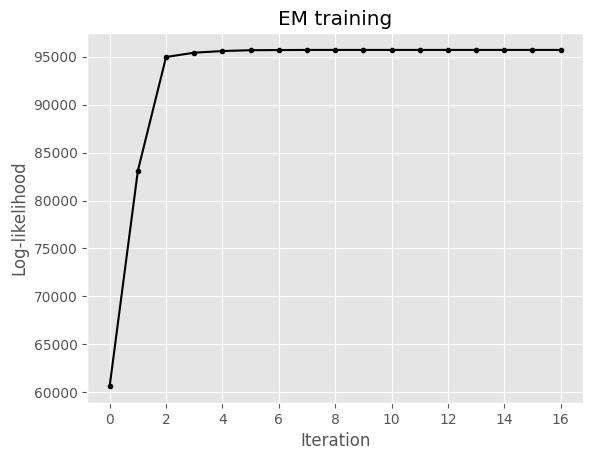

In [141]:
reg_coef = 1e-6
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=U,
    X=None,
    Y=None,
    beta=beta,
    reg_coef=reg_coef,
    tol=tol,
    seed=seed,
    allow_singular=False,
)

In [142]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 6.85105443e-01, -5.87252125e-01,  1.79247604e-01,
          2.74374471e-02,  6.73903800e-01,  6.95938919e-01,
          6.30874471e-01,  2.20480025e-02,  6.60748703e-01,
          5.55174511e-01,  7.04087989e-01,  1.31369788e-01,
          1.84346575e-01,  4.54653100e-01, -5.99669121e-01,
         -5.81190439e-01, -6.21648147e-01,  1.33376261e-02,
         -6.07984169e-01, -5.88110007e-01, -4.88798231e-01,
         -6.65452596e-01,  4.65471061e-02, -6.23585909e-01,
          2.01107527e-01,  2.66681930e-01,  1.54619897e-01,
          3.81207294e-02,  1.68970675e-01,  2.59139004e-01,
          4.90192010e-01,  1.39584667e-01,  1.20523438e-01,
          1.59502112e-01,  1.25960749e-02,  3.81163850e-02,
          1.00000000e-02,  7.24146632e-03,  1.00000000e-02,
          1.13813515e-01,  3.25634051e-01,  9.99988450e-03,
          1.37460790e-01,  1.00000000e-02],
        [ 3.74273298e-01, -5.85619639e-01,  3.02854686e-01,
          3.52779020e-01,  3.84046356e-01,  4.65312814e-

In [143]:
# traj_all.label_true, clust_labels_pred
true_labels, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [144]:
# print_metrics(X=U, labels_true=traj_all.label_true, labels_pred=clust_labels_pred)
print_metrics(X=U, labels_true=true_labels, labels_pred=clust_labels_pred)

Silhouette: 0.22318323289680395
Completeness: 0.5363050529696836
Fowlkes-Mallows index: 0.6006251221495779
Homogeneity: 0.49763465011666635
Mutual Information: 0.7724261979160717
Adjusted mutual information: 0.5134314822514794
Normalized Mutual Information: 0.5162466952254754
Rand index: 0.8075418000711491
Adjusted rand index: 0.473407262276347
V-measure: 0.5162466952254753


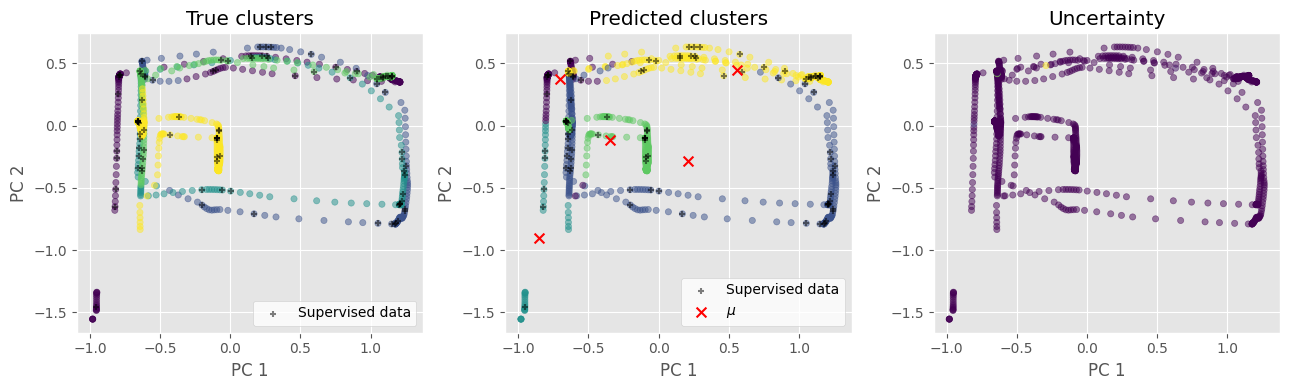

In [145]:
plot_cluster_res3(
    U=U,
    X=X,
    Y=Y,
    # labels_gt=traj_all.label_true,
    labels_gt=true_labels,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

In [146]:
def plot_cluster_res4(
    U, X, Y, labels_gt, labels_pred, gamma_resp, mu, uncertainty, proba
):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    cmap = plt.colormaps["tab10"].colors
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
        for clust_i in np.unique(labels_gt):
            if np.isnan(clust_i):
                continue
            clust_current_gt = U_pca[labels_gt == clust_i]
            clust_current_pred = U_pca[labels_pred == clust_i]
            # ax[0, 0].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=labels_gt)
            ax[0, 0].scatter(
                clust_current_gt[:, 0],
                clust_current_gt[:, 1],
                alpha=0.5,
                s=20,
                color=cmap[int(clust_i)],
                label=f"Cluster {clust_i}",
            )
            ax[0, 1].scatter(
                clust_current_pred[:, 0],
                clust_current_pred[:, 1],
                alpha=0.5,
                s=20,
                color=cmap[int(clust_i)],
                label=f"Cluster {clust_i}",
            )
        ax[0, 0].set_title("True clusters")
        # ax[0, 1].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=labels_pred)
        ax[0, 1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0, 1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="x",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[0, 1].set_title("Predicted clusters")
        scat_u = ax[1, 0].scatter(
            U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=uncertainty
        )
        ax[1, 0].set_title("Uncertainty")
        fig.colorbar(scat_u, ax=ax[1, 0])
        scat_p = ax[1, 1].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20, c=proba)
        ax[1, 1].set_title(r"$p( \mathbf{x} )$")
        fig.colorbar(scat_p, ax=ax[1, 1])
        for axi in ax.flatten():
            axi.set_xlabel("PC1")
            axi.set_ylabel("PC2")
        for axi in ax.flatten()[:2]:
            axi.legend(loc="best", facecolor="white")
        fig.tight_layout()
        if TRANSP_BACK_PLOT:
            fig.patch.set_alpha(0)
        plt.show()

In [147]:
gamma_resp, labels_pred, uncertainty, proba = predict(
    U=U,
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    allow_singular=False,
    seed=seed,
)
gamma_resp, labels_pred, uncertainty, proba

(array([[0.00000000e+000, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        ...,
        [2.67741314e-107, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [2.35085071e-112, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [3.72164588e-116, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000]], shape=(937, 5)),
 array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4,

In [148]:
# proba.min(), proba.max(), proba.sum(), proba

In [149]:
assert np.all(labels_pred == clust_labels_pred), "Issue with labels prediction"

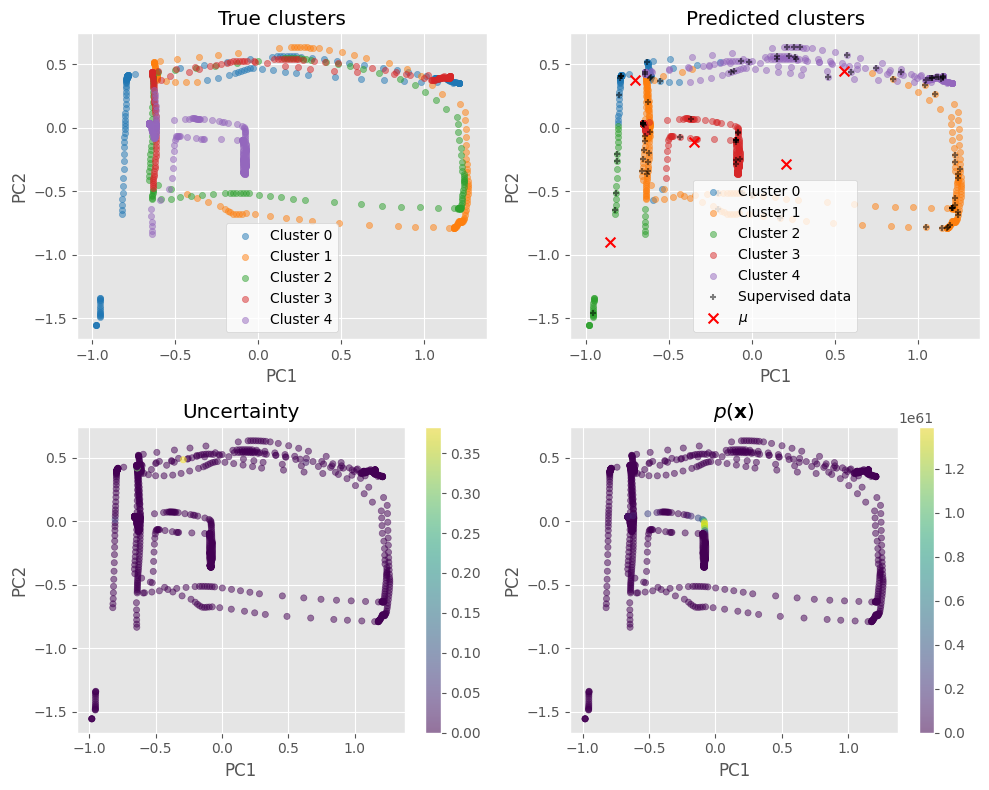

In [150]:
plot_cluster_res4(
    U=U,
    X=X,
    Y=Y,
    # labels_gt=traj_all.label_true,
    labels_gt=true_labels,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
    uncertainty=uncertainty,
    proba=proba,
)

In [151]:
def plot_segmentation_on_ts(
    traj, labels_true, labels_pred, supervised_samples, idx_superv
):

    ts = np.arange(traj.shape[0])
    classes_names = np.unique(labels_pred)
    cmap = mpl.colormaps.get("tab20").colors

    fig, axes = plt.subplots(
        nrows=len(traj.columns),
        ncols=1,
        sharex=True,
        figsize=(12, 2 * len(traj.columns)),
    )

    for idx, ax in enumerate(axes):
        for item in (
            [ax.title, ax.xaxis.label, ax.yaxis.label]
            + ax.get_xticklabels()
            + ax.get_yticklabels()
        ):
            item.set_fontsize(12)
        ax.spines[["right", "top"]].set_visible(False)
        ax.tick_params(color="gray")
        for spine in ax.spines.values():
            spine.set_edgecolor("gray")

        ax.plot(ts, traj.iloc[:, idx], "k")
        ax.set_ylabel(traj.columns[idx])
        ax.scatter(
            ts[idx_superv],
            supervised_samples[:, idx],
            marker="o",
            facecolors="none",
            edgecolors="k",
            zorder=3,
            label="Supervised data",
        )

        y_low, y_high = ax.get_ylim()
        y_mid = np.array([y_low, y_high]).mean().item()
        y_height = y_high - y_low
        for jdx, class_id in enumerate(classes_names):
            xs_pred = ts[labels_pred == class_id]
            xs_true = ts[labels_true == class_id]

            # Predicted classes
            for zdx, xi in enumerate(xs_pred):
                if zdx == 0:
                    ax.fill_between(
                        [xi - 0.5, xi + 0.5],
                        # [y_mid - y_height] * 2,
                        y_mid,
                        [y_mid + y_height] * 2,
                        alpha=0.3,
                        color=cmap[2 * jdx],
                        label=f"Predicted class {class_id}",
                    )
                else:
                    ax.fill_between(
                        [xi - 0.5, xi + 0.5],
                        # [y_mid - y_height] * 2,
                        y_mid,
                        [y_mid + y_height] * 2,
                        alpha=0.3,
                        color=cmap[2 * jdx],
                    )

            # True classes
            for zdx, xi in enumerate(xs_true):
                if zdx == 0:
                    ax.fill_between(
                        [xi - 0.5, xi + 0.5],
                        [y_mid - y_height] * 2,
                        y_mid,
                        # [y_mid + y_height] * 2,
                        alpha=0.3,
                        color=cmap[2 * jdx + 1],
                        label=f"True class {class_id}",
                    )
                else:
                    ax.fill_between(
                        [xi - 0.5, xi + 0.5],
                        # [y_mid - y_height] * 2,
                        y_mid,
                        [y_mid - y_height] * 2,
                        alpha=0.3,
                        color=cmap[2 * jdx + 1],
                    )
        ax.set_ylim(bottom=(y_mid - y_height) * 1.01, top=(y_mid + y_height) * 1.01)
    axes[-1].set_xlabel("Time step")

    axes[-1].legend(
        bbox_to_anchor=(1, -0.5), ncol=int(len(classes_names) / 2), fontsize=12
    )
    fig.suptitle(
        "Segmentation results",
        fontsize=14,
    )
    # fig.autofmt_xdate()
    fig.tight_layout()
    if TRANSP_BACK_PLOT:
        fig.patch.set_alpha(0)
    plt.show()

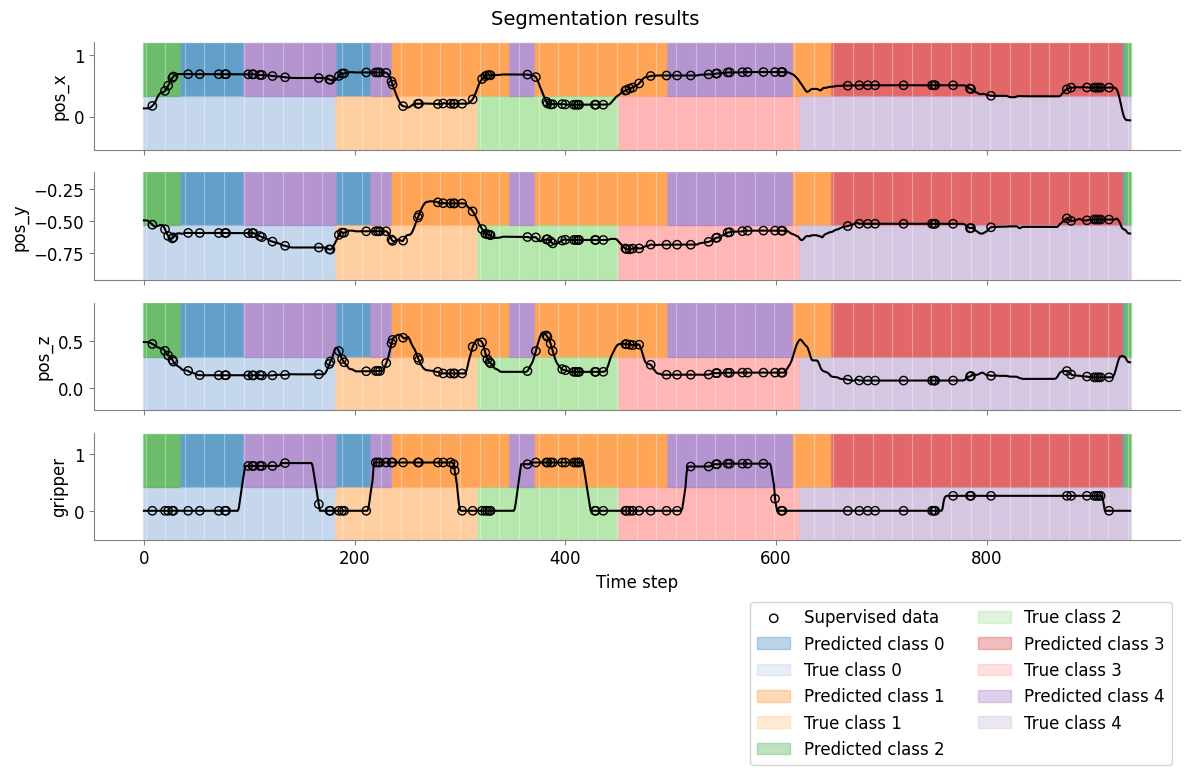

In [152]:
plot_segmentation_on_ts(
    traj=traj_all[freeze_cols],  # .drop(columns="label_true"),
    # labels_true=traj_all.label_true,
    labels_true=true_labels,
    labels_pred=clust_labels_pred,
    supervised_samples=X,
    idx_superv=idx_superv,
)